**SPLIT DATA 70:30**

**AUGMENTASI ON THE FLY**

**BATCH SIZE KLASIFIKASI 16 & 32**

**MENGGUNAKAN UNET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path folder ALPUKAT di Google Drive
project_path = '/content/drive/MyDrive/dataset'
os.chdir(project_path)


# Verifikasi isi folder
!ls

best_unet1_model.h5  images  masks


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import os
import glob
import random
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy, SparseCategoricalCrossentropy
from tensorflow.keras.metrics import MeanIoU, SparseCategoricalAccuracy
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd

In [ ]:
pip install tensorflow

In [ ]:
IMG_SIZE = 128
NUM_CLASSES = 3
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
image_paths = sorted(glob.glob('/content/drive/MyDrive/dataset/images/*.*'))  # Untuk semua tipe gambar
mask_paths = sorted(glob.glob('/content/drive/MyDrive/dataset/masks/*.*'))

print(len(image_paths))
print(len(mask_paths))

450
450


In [ ]:
label_map = {
    'miki': 0,
    'aligator': 1,
    'marcus': 2
}

labels = [label_map[os.path.basename(path).split('_')[0]] for path in image_paths]

In [ ]:
from sklearn.model_selection import train_test_split

# Gunakan stratified split untuk menjaga proporsi kelas tetap
train_image_paths, test_image_paths, train_mask_paths, test_mask_paths, train_labels, test_labels = train_test_split(
    image_paths, mask_paths, labels,
    test_size=0.3,
    stratify=labels,   # menjaga distribusi kelas
    random_state=42
)


In [ ]:
from collections import Counter

# Hitung jumlah masing-masing label di data training
label_counts = Counter(train_labels)

# Tampilkan hasilnya
for label, count in label_counts.items():
    print(f"Label {label}: {count} data")


Label 0: 105 data
Label 2: 105 data
Label 1: 105 data


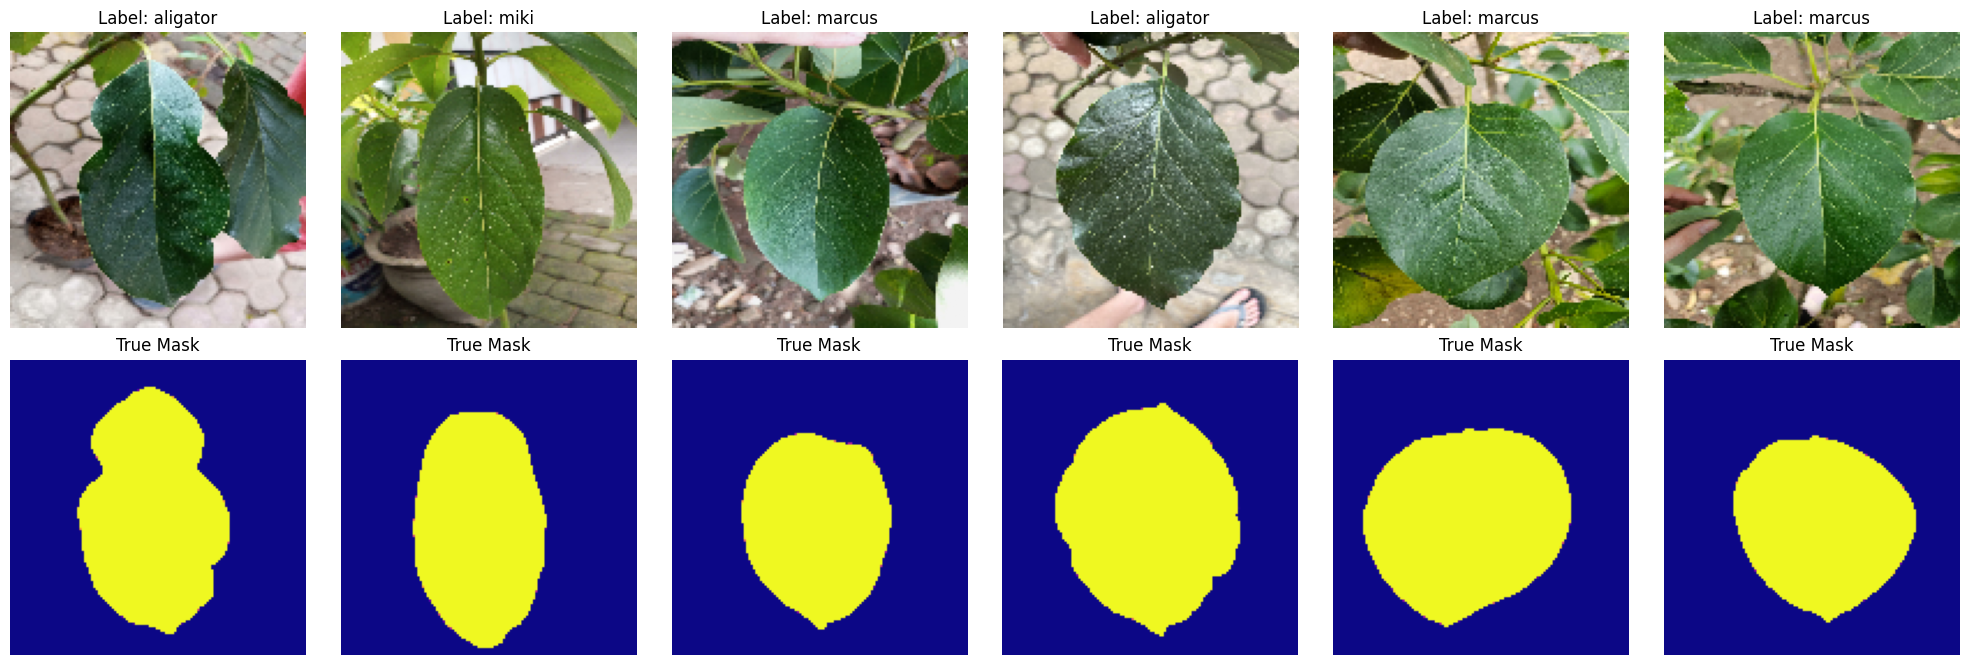

In [ ]:
# Sample 6 random image paths
sample_paths = random.sample(list(zip(image_paths, mask_paths)), 6)

plt.figure(figsize=(20, 10))

for i, (image_path, mask_path) in enumerate(sample_paths):
    # Ambil label dari nama file (misalnya, class diambil dari nama file gambar)
    class_name = os.path.basename(image_path).split('_')[0]
    label_name = class_name if class_name in label_map else 'unknown'

    # Load dan proses gambar
    img = tf.image.decode_jpeg(tf.io.read_file(image_path), channels=3)
    img = tf.image.resize(img, (128, 128)) / 255.0

    # Load dan proses mask
    mask = tf.image.decode_jpeg(tf.io.read_file(mask_path), channels=1)  # Mask grayscale
    mask = tf.image.resize(mask, (128, 128)) / 255.0  # Resize mask agar sesuai dengan gambar

    # Plot gambar asli
    plt.subplot(3, 6, i + 1)  # Baris 1, Gambar asli
    plt.imshow(img)
    plt.title(f"Label: {label_name}")
    plt.axis('off')

    # Plot true mask
    plt.subplot(3, 6, i + 7)  # Baris 2, True mask
    plt.imshow(mask, cmap='plasma')  # Gunakan colormap untuk visualisasi mask
    plt.title("True Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()

##**DATA PREPROCESSINGG DAN AUGMENTASI**##

In [ ]:
import tensorflow as tf

# Fungsi preprocessing gambar dan mask
def load_and_preprocess_image(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [128, 128])
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [128, 128])
    mask = tf.cast(mask, tf.float32) / 255.0

    # Thresholding untuk membentuk mask biner
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return image, mask


In [ ]:
import tensorflow as tf

def augment_unet(image_path, mask_path):
    image, mask = load_and_preprocess_image(image_path, mask_path)

    # Augmentasi flip horizontal
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    # Augmentasi flip vertikal
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    # Augmentasi rotasi (90, 180, 270, 0)
    rotations = [0, 90, 180, 270]
    rotation_angle = tf.random.shuffle(rotations)[0]
    image = tf.image.rot90(image, k=rotation_angle // 90)
    mask = tf.image.rot90(mask, k=rotation_angle // 90)

    # Augmentasi transpose
    if tf.random.uniform(()) > 0.5:
        image = tf.image.transpose(image)
        mask = tf.image.transpose(mask)

    return image, mask

In [ ]:
train_unet_ds = tf.data.Dataset.from_tensor_slices((train_image_paths, train_mask_paths))
train_unet_ds = train_unet_ds.map(augment_unet, num_parallel_calls=AUTOTUNE)
train_unet_ds = train_unet_ds.shuffle(100).batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_unet_ds = tf.data.Dataset.from_tensor_slices((test_image_paths, test_mask_paths))
test_unet_ds = test_unet_ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
test_unet_ds = test_unet_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [ ]:
# for image, mask in train_unet_ds.take(1):
#     print("Image shape:", image.shape)
#     print("Mask shape:", mask.shape)


##**UNET MODEL**##

In [ ]:
def double_conv_block(x, n_filters):
    x = layers.Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool2D(2)(f)
    p = layers.Dropout(0.3)(p)
    return f, p

def upsample_block(x, conv_features, n_filters):
    x = layers.Conv2DTranspose(n_filters, 3, 2, padding='same')(x)
    x = layers.concatenate([x, conv_features])
    x = layers.Dropout(0.3)(x)
    x = double_conv_block(x, n_filters)
    return x

In [ ]:
# --- U-Net Segmentasi ---
def build_unet():
    inputs = layers.Input(shape=(128, 128, 3))

    # Encoder
    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)

    # Bottleneck
    bottleneck = double_conv_block(p4, 1024)

    # Decoder
    u6 = upsample_block(bottleneck, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    # Output segmentasi
    segmentation_output = layers.Conv2D(1, (1, 1), activation='sigmoid', name='segmentation')(u9)

    model = models.Model(inputs=inputs, outputs=segmentation_output, name='U-Net-Segmenter')
    return model

In [ ]:
# Membuat model U-Net
unet_model = build_unet()

# Menampilkan summary dari model U-Net
unet_model.summary()

Model: "U-Net-Segmenter"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16, 16,    │          0 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ dropout_2[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 8, 8, 512) │          0 │ max_pooling2d_3[

 Total params: 34,513,345 (131.66 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def iou_metric(y_true, y_pred, smooth=1e-6):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # Menggunakan threshold 0.5 untuk prediksi
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou

In [ ]:
# Kompilasi model
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Ganti dengan IoU loss jika sudah didefinisikan
    metrics=[iou_metric]
)

# Definisikan callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_unet1_model.h5', save_best_only=True, monitor='val_loss', mode='min')
]

In [ ]:
# Melatih model
history = unet_model.fit(
    train_unet_ds,
    epochs=100,
    validation_data=test_unet_ds,
    steps_per_epoch=len(train_unet_ds),
    validation_steps=len(test_unet_ds),
    callbacks=callbacks
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - iou_metric: 0.0481 - loss: 0.6205

20/20 ━━━━━━━━━━━━━━━━━━━━ 338s 11s/step - iou_metric: 0.0490 - loss: 0.6162 - val_iou_metric: 0.5419 - val_loss: 0.3735
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.4729 - loss: 0.3767

20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - iou_metric: 0.4740 - loss: 0.3758 - val_iou_metric: 0.5736 - val_loss: 0.3191
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.5297 - loss: 0.3393

20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - iou_metric: 0.5302 - loss: 0.3388 - val_iou_metric: 0.5973 - val_loss: 0.3010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.5735 - loss: 0.3076

20/20 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step - iou_metric: 0.5737 - loss: 0.3072 - val_iou_metric: 0.6416 - val_loss: 0.2480
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.6133 - loss: 0.2716

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - iou_metric: 0.9451 - loss: 0.0378 - val_iou_metric: 0.9594 - val_loss: 0.0274
Epoch 36/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - iou_metric: 0.9498 - loss: 0.0345

20/20 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - iou_metric: 0.9499 - loss: 0.0344 - val_iou_metric: 0.9623 - val_loss: 0.0246
Epoch 37/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - iou_metric: 0.9528 - loss: 0.0339 - val_iou_metric: 0.9603 - val_loss: 0.0262
Epoch 38/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - iou_metric: 0.9556 - loss: 0.0308 - val_iou_metric: 0.9599 - val_loss: 0.0283
Epoch 39/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - iou_metric: 0.9609 - loss: 0.0267 - val_iou_metric: 0.9618 - val_loss: 0.0258
Epoch 40/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - iou_metric: 0.9581 - loss: 0.0290 - val_iou_metric: 0.9570 - val_loss: 0.0311
Epoch 41/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - iou_metric: 0.9503 - loss: 0.0356 - val_iou_metric: 0.9531 - val_loss: 0.0315
Epoch 42/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - iou_metric: 0.9522 - loss: 0.0338 - val_iou_metric: 0.9606 - val_loss: 0.0267
Epoch 43/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - iou_metric: 0.9585 - loss: 0.0287

20/20 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - iou_metric: 0.9584 - loss: 0.0287 - val_iou_metric: 0.9643 - val_loss: 0.0242
Epoch 44/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.9624 - loss: 0.0264

20/20 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - iou_metric: 0.9625 - loss: 0.0263 - val_iou_metric: 0.9686 - val_loss: 0.0208
Epoch 45/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - iou_metric: 0.9623 - loss: 0.0261 - val_iou_metric: 0.9582 - val_loss: 0.0290
Epoch 46/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - iou_metric: 0.9624 - loss: 0.0264

20/20 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - iou_metric: 0.9625 - loss: 0.0263 - val_iou_metric: 0.9700 - val_loss: 0.0192
Epoch 47/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - iou_metric: 0.9629 - loss: 0.0239 - val_iou_metric: 0.9624 - val_loss: 0.0254
Epoch 48/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - iou_metric: 0.9575 - loss: 0.0287 - val_iou_metric: 0.9625 - val_loss: 0.0267
Epoch 49/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - iou_metric: 0.9583 - loss: 0.0315 - val_iou_metric: 0.9672 - val_loss: 0.0251
Epoch 50/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - iou_metric: 0.9556 - loss: 0.0318 - val_iou_metric: 0.9666 - val_loss: 0.0241
Epoch 51/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - iou_metric: 0.9592 - loss: 0.0271 - val_iou_metric: 0.9692 - val_loss: 0.0214
Epoch 52/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - iou_metric: 0.9626 - loss: 0.0255 - val_iou_metric: 0.9686 - val_loss: 0.0213
Epoch 53/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - iou_metric: 0.9579 - loss: 0.0303 -

In [ ]:
# Simpan history ke file JSON
history_dict = history.history
with open('training_history1.json', 'w') as json_file:
    json.dump(history_dict, json_file)

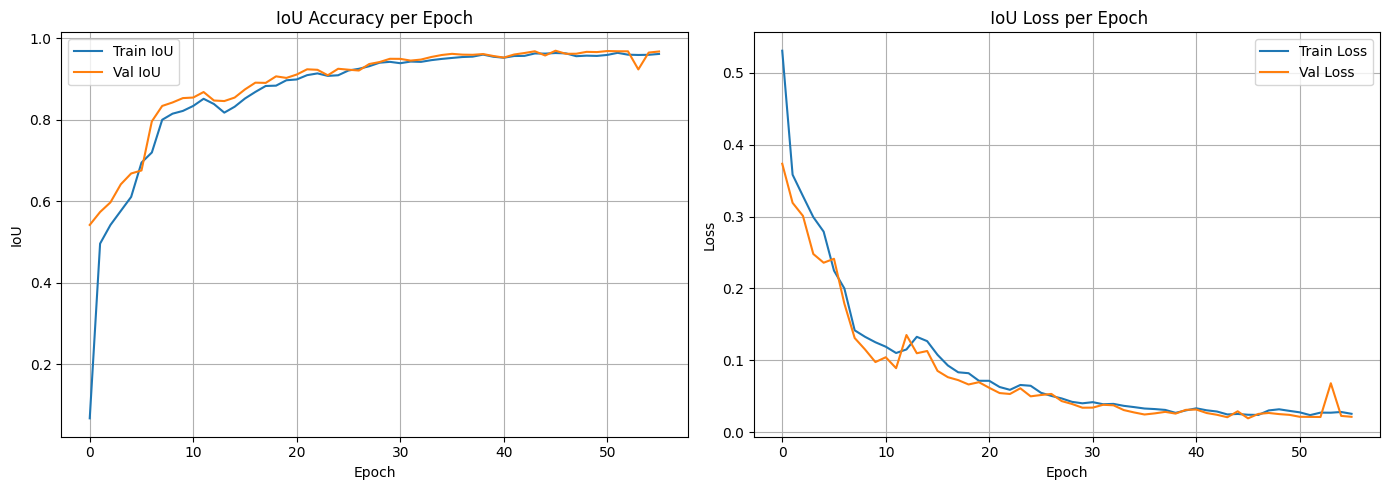

In [ ]:
# Ekstrak data dari history
history_dict = history.history

# Buat plot
plt.figure(figsize=(14, 5))

# Plot IoU (iou_metric)
plt.subplot(1, 2, 1)
plt.plot(history_dict['iou_metric'], label='Train IoU')
plt.plot(history_dict['val_iou_metric'], label='Val IoU')
plt.title('IoU Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title(' IoU Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


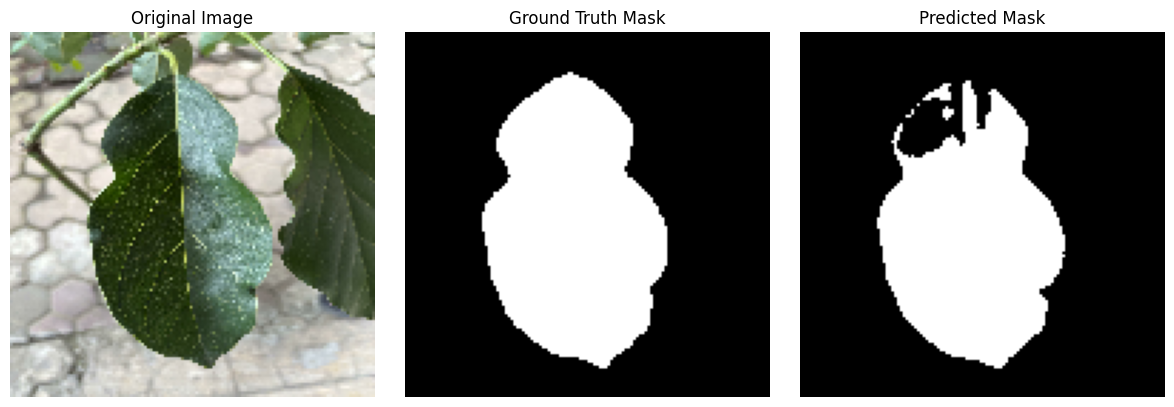

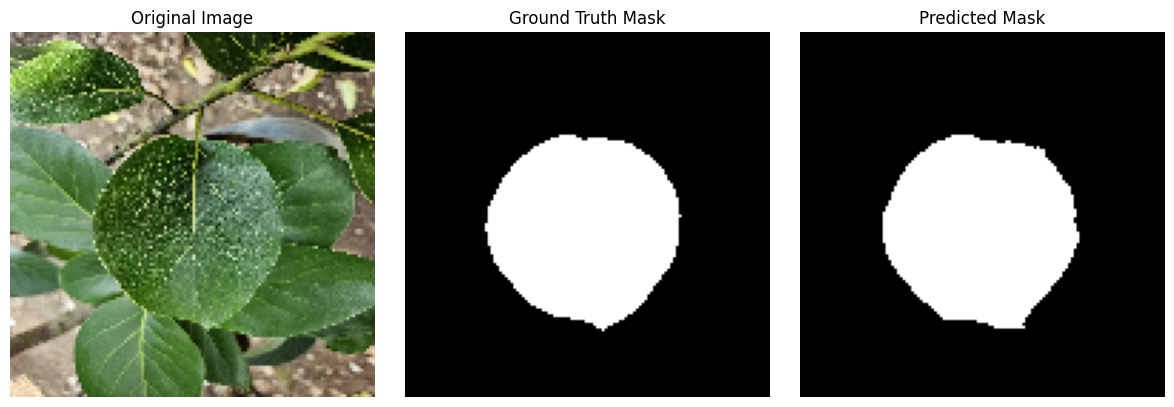

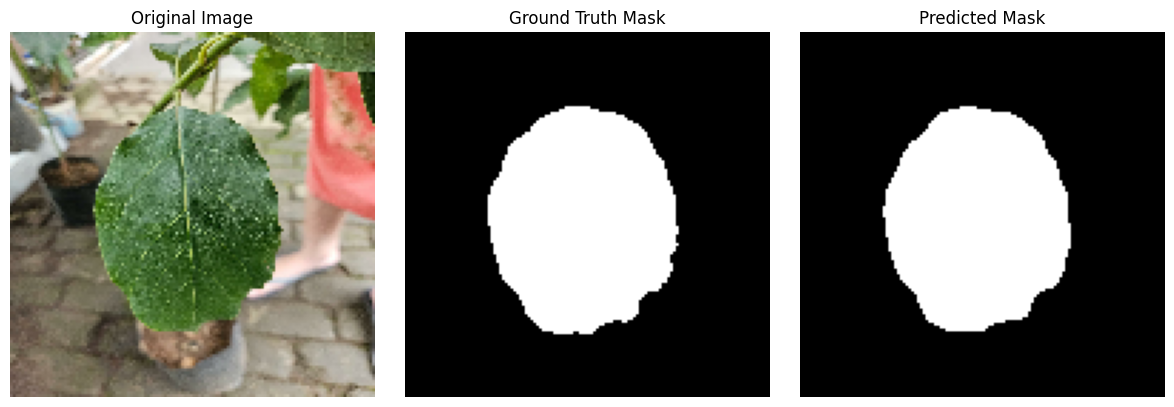

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def display_sample_prediction(unet_model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = unet_model.predict(images)
        preds = (preds > 0.5).astype(np.uint8)  # Threshold prediksi

        for i in range(num_samples):
            image = images[i].numpy()
            gt_mask = masks[i].numpy().squeeze()
            pred_mask = preds[i].squeeze()

            plt.figure(figsize=(12, 4))

            # Gambar asli
            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Original Image")
            plt.axis('off')

            # Ground truth mask
            plt.subplot(1, 3, 2)
            plt.imshow(gt_mask, cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')

            # Predicted mask
            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='gray')
            plt.title("Predicted Mask")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

display_sample_prediction(unet_model, test_unet_ds, num_samples=3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step


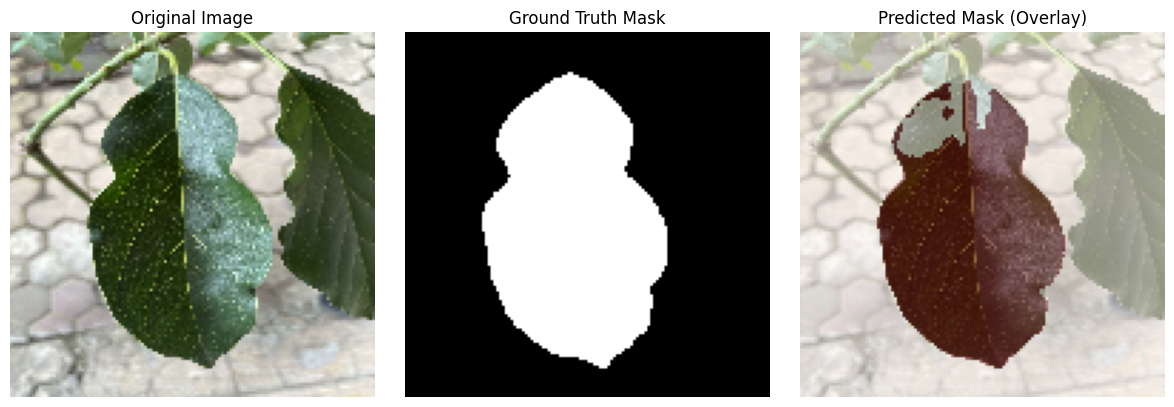

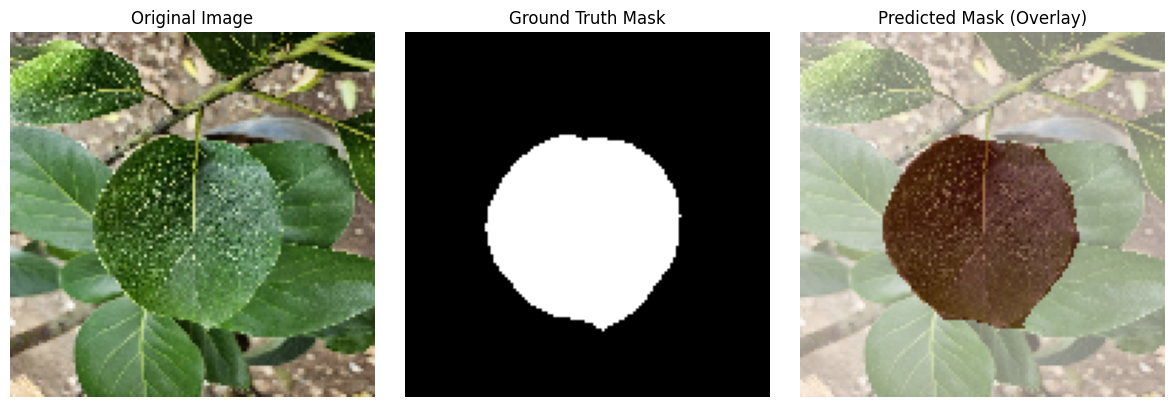

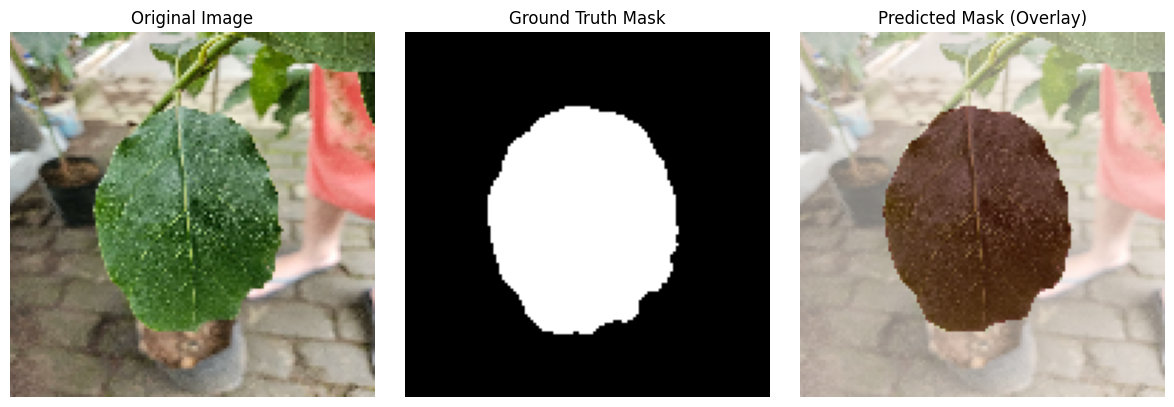

In [ ]:
def display_sample_prediction(unet_model, dataset, num_samples=3):
    for images, masks in dataset.take(1):
        preds = unet_model.predict(images)
        preds = (preds > 0.5).astype(np.uint8)  # Threshold prediksi

        for i in range(num_samples):
            image = images[i].numpy()
            gt_mask = masks[i].numpy().squeeze()
            pred_mask = preds[i].squeeze()

            plt.figure(figsize=(12, 4))

            # Gambar asli
            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Original Image")
            plt.axis('off')

            # Ground truth mask
            plt.subplot(1, 3, 2)
            plt.imshow(gt_mask, cmap='gray')
            plt.title("Ground Truth Mask")
            plt.axis('off')

            # Predicted mask overlay dengan gambar asli
            plt.subplot(1, 3, 3)
            plt.imshow(image)
            plt.imshow(pred_mask, cmap='Reds', alpha=0.5)  # Overlay mask
            plt.title("Predicted Mask (Overlay)")
            plt.axis('off')

            plt.tight_layout()
            plt.show()

display_sample_prediction(unet_model, test_unet_ds, num_samples=3)

##**CLASSIFICATION MODEL**##

In [ ]:
# from tensorflow.keras.models import load_model

# # Load model U-Net dari checkpoint
# unet_model = load_model('/content/drive/MyDrive/alpukat/dataset/best_unet1_model.h5')

In [ ]:
# Gunakan lowercase untuk key
keys_tensor = tf.constant([k.lower() for k in label_map.keys()])
vals_tensor = tf.constant(list(label_map.values()), dtype=tf.int32)
table_init = tf.lookup.KeyValueTensorInitializer(keys_tensor, vals_tensor)
label_table = tf.lookup.StaticHashTable(table_init, default_value=-1)

def extract_label_from_filename_tf(filename):
    filename = tf.strings.lower(filename)
    label_str = tf.strings.split(filename, '_')[0]
    return label_table.lookup(label_str)

In [ ]:
def apply_unet_segmentation_to_image(image, segmentation_output, threshold=0.5):
    if isinstance(image, tf.Tensor):
        image = tf.cast(image, tf.float32)

    if image.shape[-1] != 3:
        raise ValueError(f"Image must have 3 channels. Got shape: {image.shape}")

    binary_mask = tf.cast(segmentation_output > threshold, tf.float32)
    if len(binary_mask.shape) == 2:
        binary_mask = tf.expand_dims(binary_mask, axis=-1)
    binary_mask_rgb = tf.repeat(binary_mask, repeats=3, axis=-1)

    if binary_mask_rgb.shape != image.shape:
        binary_mask_rgb = tf.image.resize(binary_mask_rgb, image.shape[:2])

    masked_image = image * binary_mask_rgb
    return masked_image

In [ ]:
from tqdm import tqdm

def save_masked_dataset(image_paths, unet_model, save_dir, image_size=(128, 128)):
    os.makedirs(save_dir, exist_ok=True)
    for path in tqdm(image_paths):
        # Load & resize
        image_raw = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image_raw, channels=3)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0

        # Predict mask
        pred = unet_model(tf.expand_dims(image, 0), training=False)
        pred = tf.squeeze(pred, axis=0)

        # Apply mask
        masked_image = apply_unet_segmentation_to_image(image, pred)

        # Simpan hasil
        fname = os.path.basename(path)
        save_path = os.path.join(save_dir, fname)
        masked_uint8 = tf.image.convert_image_dtype(masked_image, tf.uint8)
        encoded = tf.image.encode_jpeg(masked_uint8)
        tf.io.write_file(save_path, encoded)


In [ ]:
save_masked_dataset(train_image_paths, unet_model, "maskedunet1_train")
save_masked_dataset(test_image_paths, unet_model, "maskedunet1_test")

100%|██████████| 135/135 [00:28<00:00,  4.81it/s]


In [ ]:
def load_masked_dataset(image_dir):
    image_paths = tf.io.gfile.glob(os.path.join(image_dir, '*.jpg'))
    ds = tf.data.Dataset.from_tensor_slices(image_paths)

    def load_image_and_label(path):
        image_raw = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image_raw, channels=3)
        image = tf.image.resize(image, [128, 128])
        image = tf.cast(image, tf.float32) / 255.0

        filename = tf.strings.split(path, '/')[-1]
        label = extract_label_from_filename_tf(filename)
        return image, label

    return ds.map(load_image_and_label, num_parallel_calls=tf.data.AUTOTUNE)


In [ ]:
# Batching dan prefetch
classification_train_ds_16 = load_masked_dataset("maskedunet1_train").batch(16).prefetch(tf.data.AUTOTUNE)
classification_test_ds_16 = load_masked_dataset("maskedunet1_test").batch(16).prefetch(tf.data.AUTOTUNE)

classification_train_ds_32 = load_masked_dataset("maskedunet1_train").batch(32).prefetch(tf.data.AUTOTUNE)
classification_test_ds_32 = load_masked_dataset("maskedunet1_test").batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# def extract_label_from_filename(filename):
#     filename_str = filename.numpy().decode() if isinstance(filename, tf.Tensor) else str(filename)
#     label_name = filename_str.split('_')[0].lower()
#     return tf.constant(labell_map.get(label_name, -1))  # -1

In [ ]:
# def apply_unet_segmentation_to_image(image, segmentation_output, threshold=0.5):
#     if isinstance(image, tf.Tensor):
#         image = tf.cast(image, tf.float32)

#     if image.shape[-1] != 3:
#         raise ValueError(f"Image must have 3 channels. Got shape: {image.shape}")

#     binary_mask = tf.cast(segmentation_output > threshold, tf.float32)
#     if len(binary_mask.shape) == 2:
#         binary_mask = tf.expand_dims(binary_mask, axis=-1)
#     binary_mask_rgb = tf.repeat(binary_mask, repeats=3, axis=-1)

#     if binary_mask_rgb.shape != image.shape:
#         binary_mask_rgb = tf.image.resize(binary_mask_rgb, image.shape[:2])

#     masked_image = image * binary_mask_rgb
#     return masked_image

# def extract_and_apply_mask(image, unet_model):
#     image_expanded = tf.expand_dims(image, 0)
#     pred_mask = unet_model(image_expanded, training=False)
#     pred_mask = tf.squeeze(pred_mask, axis=0)
#     return apply_unet_segmentation_to_image(image, pred_mask)

In [ ]:
# def create_classification_dataset(image_paths, unet_model):
#     images, labels = [], []

#     for path in image_paths:
#         path = str(path)
#         filename = tf.strings.split(path, '/')[-1]
#         label_tensor = extract_label_from_filename(filename)
#         label = int(label_tensor.numpy())

#         image_raw = tf.io.read_file(path)
#         image = tf.image.decode_jpeg(image_raw, channels=3)
#         image = tf.image.resize(image, [128, 128])
#         image = tf.cast(image, tf.float32) / 255.0

#         masked_image = extract_and_apply_mask(image, unet_model)

#         images.append(masked_image)
#         labels.append(label)

#     dataset = tf.data.Dataset.from_tensor_slices((images, labels))
#     return dataset.shuffle(100).prefetch(tf.data.AUTOTUNE)

In [ ]:
# # Membuat dataset
# classification_train_ds_16 = create_classification_dataset(train_image_paths, unet_model)
# classification_test_ds_16 = create_classification_dataset(test_image_paths, unet_model)

# # Batching di luar fungsi create_classification_dataset
# classification_train_ds_16 = classification_train_ds_16.batch(16).prefetch(tf.data.AUTOTUNE)
# classification_test_ds_16 = classification_test_ds_16.batch(16).prefetch(tf.data.AUTOTUNE)

# classification_train_ds_32 = create_classification_dataset(train_image_paths, unet_model)
# classification_test_ds_32 = create_classification_dataset(test_image_paths, unet_model)

# classification_train_ds_32 = classification_train_ds_32.batch(32).prefetch(tf.data.AUTOTUNE)
# classification_test_ds_32 = classification_test_ds_32.batch(32).prefetch(tf.data.AUTOTUNE)


In [ ]:
def classification_model(input_shape=(128, 128, 3)):
    inputs = tf.keras.layers.Input(input_shape)

    x = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

    return tf.keras.models.Model(inputs, outputs)


In [ ]:
clf_model_class1 = classification_model()
clf_model_class2 = classification_model()

clf_model_class1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,699 (397.26 KB)

 Trainable params: 101,699 (397.26 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
clf_model_class1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

clf_model_class2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Definisikan callbacks
callbacks_class1 = [
    ModelCheckpoint('best_class1_unet1.h5', save_best_only=True, monitor='val_loss', mode='min')
]

callbacks_class2 = [
    ModelCheckpoint('best_class2_unet1.h5', save_best_only=True, monitor='val_loss', mode='min')
]

##***TRAINING CLASS BS 16***##

In [ ]:
history_class1 = clf_model_class1.fit(
    classification_train_ds_16,   # dataset sudah dibatch dengan batch size 16
    validation_data=classification_test_ds_16,   # dataset validation juga sudah dibatch
    epochs=100,
    callbacks=callbacks_class1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.3565 - loss: 1.1007

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.3562 - loss: 1.1008 - val_accuracy: 0.3333 - val_loss: 1.0982
Epoch 2/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3113 - loss: 1.0986

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.3119 - loss: 1.0986 - val_accuracy: 0.3333 - val_loss: 1.0975
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3151 - loss: 1.0980

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3163 - loss: 1.0980 - val_accuracy: 0.4000 - val_loss: 1.0935
Epoch 4/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4413 - loss: 1.0908

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.4392 - loss: 1.0906 - val_accuracy: 0.3333 - val_loss: 1.0855
Epoch 5/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3375 - loss: 1.0939

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - accuracy: 0.8696 - loss: 0.2975 - val_accuracy: 0.9259 - val_loss: 0.2149
Epoch 57/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9193 - loss: 0.2293

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9197 - loss: 0.2285 - val_accuracy: 0.9037 - val_loss: 0.2051
Epoch 58/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9295 - loss: 0.2128 - val_accuracy: 0.9259 - val_loss: 0.2347
Epoch 59/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.9026 - loss: 0.2358 - val_accuracy: 0.9185 - val_loss: 0.2240
Epoch 60/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8999 - loss: 0.2575 - val_accuracy: 0.9111 - val_loss: 0.2450
Epoch 61/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9281 - loss: 0.1996 - val_accuracy: 0.9111 - val_loss: 0.2151
Epoch 62/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9334 - loss: 0.1756 - val_accuracy: 0.9185 - val_loss: 0.2166
Epoch 63/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9142 - loss: 0.2405 - val_accuracy: 0.9111 - val_loss: 0.2913
Epoch 64/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.8807 - loss: 0.2649 - val_accuracy: 0.9111 

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.9214 - loss: 0.1920 - val_accuracy: 0.9111 - val_loss: 0.2029
Epoch 72/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.9199 - loss: 0.1841 - val_accuracy: 0.9111 - val_loss: 0.2980
Epoch 73/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9131 - loss: 0.2213

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9140 - loss: 0.2194 - val_accuracy: 0.9333 - val_loss: 0.1931
Epoch 74/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.9238 - loss: 0.1952 - val_accuracy: 0.9111 - val_loss: 0.2227
Epoch 75/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.9351 - loss: 0.1701 - val_accuracy: 0.9185 - val_loss: 0.2646
Epoch 76/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9251 - loss: 0.2228 - val_accuracy: 0.9037 - val_loss: 0.2207
Epoch 77/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.9549 - loss: 0.1468 - val_accuracy: 0.9111 - val_loss: 0.2644
Epoch 78/100
19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9001 - loss: 0.2500

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.9030 - loss: 0.2456 - val_accuracy: 0.9185 - val_loss: 0.1844
Epoch 79/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9591 - loss: 0.1361 - val_accuracy: 0.9185 - val_loss: 0.2324
Epoch 80/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9152 - loss: 0.2453 - val_accuracy: 0.9185 - val_loss: 0.2264
Epoch 81/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9187 - loss: 0.1849 - val_accuracy: 0.9185 - val_loss: 0.1852
Epoch 82/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.9420 - loss: 0.1728 - val_accuracy: 0.9259 - val_loss: 0.1879
Epoch 83/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9441 - loss: 0.1414 - val_accuracy: 0.8889 - val_loss: 0.3069
Epoch 84/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9333 - loss: 0.2004 - val_accuracy: 0.9185 - val_loss: 0.2414
Epoch 85/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.9206 - loss: 0.1906 - val_accuracy: 0.9037

In [ ]:
label_map = {
    0: "miki",
    1: "aligator",
    2: "marcus"
}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step


<Figure size 800x600 with 0 Axes>

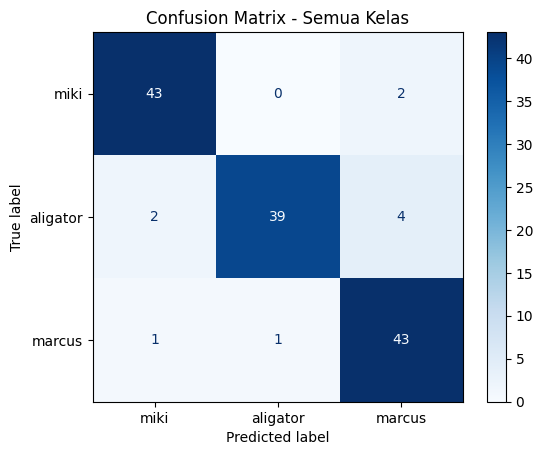

Classification Report - Semua Kelas:
              precision    recall  f1-score   support

        miki       0.93      0.96      0.95        45
    aligator       0.97      0.87      0.92        45
      marcus       0.88      0.96      0.91        45

    accuracy                           0.93       135
   macro avg       0.93      0.93      0.93       135
weighted avg       0.93      0.93      0.93       135

              precision    recall  f1-score     support
miki           0.934783  0.955556  0.945055   45.000000
aligator       0.975000  0.866667  0.917647   45.000000
marcus         0.877551  0.955556  0.914894   45.000000
accuracy       0.925926  0.925926  0.925926    0.925926
macro avg      0.929111  0.925926  0.925865  135.000000
weighted avg   0.929111  0.925926  0.925865  135.000000


In [ ]:
# Inisialisasi
y_true_all = []
y_pred_all = []

# Loop untuk mengumpulkan prediksi dan label dari seluruh test data
for image_batch, label_batch in classification_test_ds_16:
    predictions = clf_model_class1.predict(image_batch)
    predicted_labels = tf.argmax(predictions, axis=1).numpy()

    y_true_all.extend(label_batch.numpy())
    y_pred_all.extend(predicted_labels)

# Confusion Matrix
cm = confusion_matrix(y_true_all, y_pred_all)
display_labels = [label_map[i] for i in sorted(set(y_true_all + y_pred_all))]  # label_map = {0: "Kelas 1", 1: "Kelas 2", 2: "Kelas 3"}
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# Visualisasi
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Semua Kelas")
plt.grid(False)
plt.show()

# Classification Report
print("Classification Report - Semua Kelas:")
print(classification_report(y_true_all, y_pred_all, target_names=display_labels))

# (Opsional) Tampilkan sebagai DataFrame
report_df = pd.DataFrame(
    classification_report(
        y_true_all,
        y_pred_all,
        target_names=display_labels,
        output_dict=True
)
).transpose()
print(report_df)

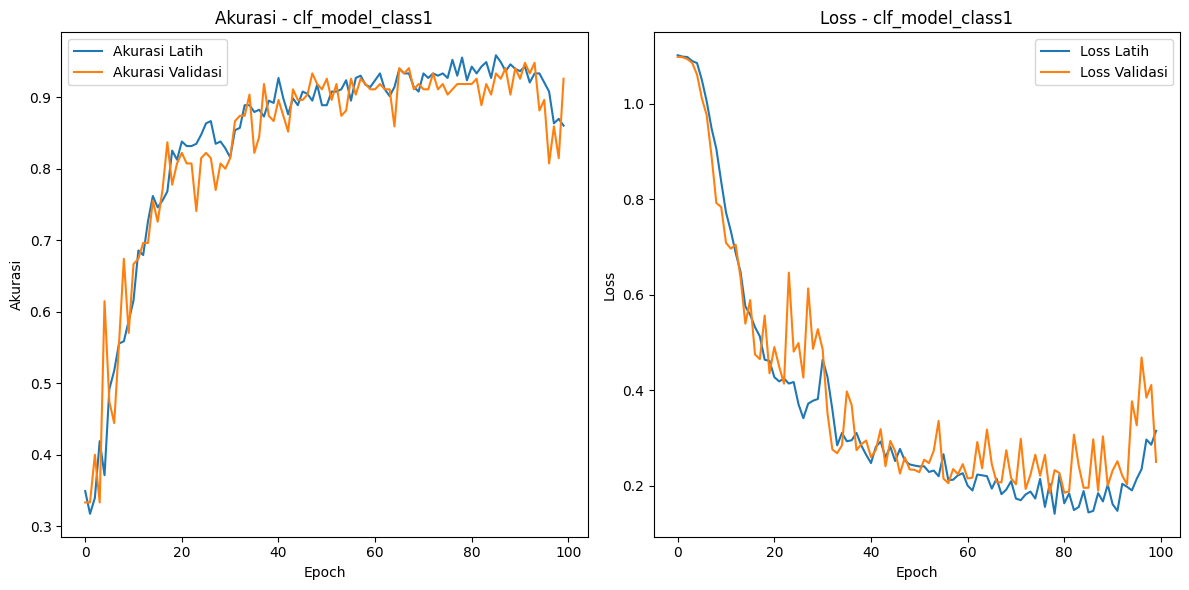

In [ ]:
import matplotlib.pyplot as plt

# Plot History untuk clf_model_class1
plt.figure(figsize=(12, 6))

# Plot Akurasi dan Loss untuk clf_model_class1
plt.subplot(1, 2, 1)  # Subplot pertama untuk akurasi
plt.plot(history_class1.history['accuracy'], label='Akurasi Latih')
plt.plot(history_class1.history['val_accuracy'], label='Akurasi Validasi')
plt.title("Akurasi - clf_model_class1")
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='best')

plt.subplot(1, 2, 2)  # Subplot kedua untuk loss
plt.plot(history_class1.history['loss'], label='Loss Latih')
plt.plot(history_class1.history['val_loss'], label='Loss Validasi')
plt.title("Loss - clf_model_class1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

##***TRAINING CLASS BS 32***##

In [ ]:
history_class2 = clf_model_class2.fit(
    classification_train_ds_32,   # dataset sudah dibatch dengan batch size 32
    validation_data=classification_test_ds_32,   # dataset validation juga sudah dibatch
    epochs=100,
    callbacks=callbacks_class2
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.2928 - loss: 1.1003

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 602ms/step - accuracy: 0.2965 - loss: 1.1001 - val_accuracy: 0.3333 - val_loss: 1.0958
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3046 - loss: 1.1046

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.3072 - loss: 1.1042 - val_accuracy: 0.3333 - val_loss: 1.0942
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3412 - loss: 1.0957

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - accuracy: 0.3408 - loss: 1.0957 - val_accuracy: 0.3333 - val_loss: 1.0909
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3149 - loss: 1.0939

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.3195 - loss: 1.0935 - val_accuracy: 0.3333 - val_loss: 1.0817
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3072 - loss: 1.0924

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 0.8850 - loss: 0.3340 - val_accuracy: 0.8519 - val_loss: 0.3125
Epoch 44/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.8846 - loss: 0.3406 - val_accuracy: 0.8444 - val_loss: 0.3245
Epoch 45/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.8394 - loss: 0.3990 - val_accuracy: 0.8593 - val_loss: 0.3342
Epoch 46/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8737 - loss: 0.3666

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.8722 - loss: 0.3682 - val_accuracy: 0.8593 - val_loss: 0.3056
Epoch 47/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.8352 - loss: 0.3707 - val_accuracy: 0.8519 - val_loss: 0.3542
Epoch 48/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.8781 - loss: 0.3423 - val_accuracy: 0.8444 - val_loss: 0.3220
Epoch 49/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.8788 - loss: 0.3519 - val_accuracy: 0.8370 - val_loss: 0.3486
Epoch 50/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step - accuracy: 0.8910 - loss: 0.2848 - val_accuracy: 0.8370 - val_loss: 0.3359
Epoch 51/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.8652 - loss: 0.3283 - val_accuracy: 0.8593 - val_loss: 0.3079
Epoch 52/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.8957 - loss: 0.2856

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 0.8951 - loss: 0.2858 - val_accuracy: 0.8889 - val_loss: 0.2821
Epoch 53/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8864 - loss: 0.3104 - val_accuracy: 0.8444 - val_loss: 0.2949
Epoch 54/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.9031 - loss: 0.2765 - val_accuracy: 0.8593 - val_loss: 0.2883
Epoch 55/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.8787 - loss: 0.3022 - val_accuracy: 0.8444 - val_loss: 0.2970
Epoch 56/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8991 - loss: 0.2610 - val_accuracy: 0.8741 - val_loss: 0.2842
Epoch 57/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.8898 - loss: 0.2516 - val_accuracy: 0.8444 - val_loss: 0.2828
Epoch 58/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8943 - loss: 0.2750

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step - accuracy: 0.8943 - loss: 0.2745 - val_accuracy: 0.8963 - val_loss: 0.2689
Epoch 59/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9099 - loss: 0.2469 - val_accuracy: 0.8519 - val_loss: 0.3405
Epoch 60/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.8506 - loss: 0.3376 - val_accuracy: 0.8519 - val_loss: 0.3672
Epoch 61/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 175ms/step - accuracy: 0.8616 - loss: 0.3429 - val_accuracy: 0.8667 - val_loss: 0.3232
Epoch 62/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.9063 - loss: 0.3056 - val_accuracy: 0.8667 - val_loss: 0.2769
Epoch 63/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.9067 - loss: 0.2526 - val_accuracy: 0.8593 - val_loss: 0.2757
Epoch 64/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.9244 - loss: 0.2133 - val_accuracy: 0.8667 - val_loss: 0.2812
Epoch 65/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.8632 - loss: 0.3481 - val_accuracy:

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.9057 - loss: 0.2400 - val_accuracy: 0.8963 - val_loss: 0.2688
Epoch 93/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.9110 - loss: 0.2745 - val_accuracy: 0.8815 - val_loss: 0.3085
Epoch 94/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.8849 - loss: 0.2928 - val_accuracy: 0.8889 - val_loss: 0.2902
Epoch 95/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.9036 - loss: 0.2663 - val_accuracy: 0.8889 - val_loss: 0.2810
Epoch 96/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.8780 - loss: 0.2587 - val_accuracy: 0.8815 - val_loss: 0.2762
Epoch 97/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.8946 - loss: 0.2430 - val_accuracy: 0.9037 - val_loss: 0.2767
Epoch 98/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.9035 - loss: 0.2559 - val_accuracy: 0.8889 - val_loss: 0.2987
Epoch 99/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 155ms/step - accuracy: 0.8830 - loss: 0.2906 - val_accuracy:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step


<Figure size 800x600 with 0 Axes>

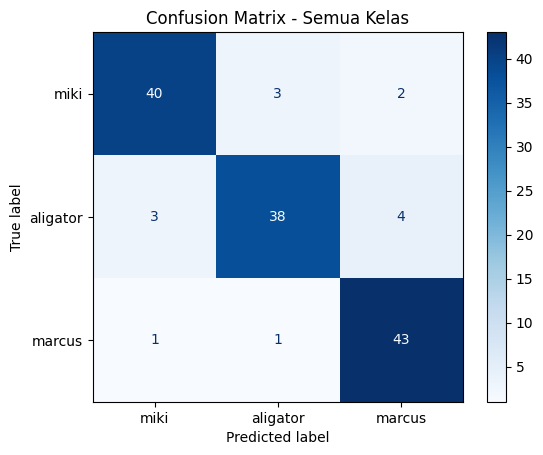

Classification Report - Semua Kelas:
              precision    recall  f1-score   support

        miki       0.91      0.89      0.90        45
    aligator       0.90      0.84      0.87        45
      marcus       0.88      0.96      0.91        45

    accuracy                           0.90       135
   macro avg       0.90      0.90      0.90       135
weighted avg       0.90      0.90      0.90       135

              precision    recall  f1-score     support
miki           0.909091  0.888889  0.898876   45.000000
aligator       0.904762  0.844444  0.873563   45.000000
marcus         0.877551  0.955556  0.914894   45.000000
accuracy       0.896296  0.896296  0.896296    0.896296
macro avg      0.897135  0.896296  0.895778  135.000000
weighted avg   0.897135  0.896296  0.895778  135.000000


In [ ]:
# Inisialisasi
y_true_all2 = []
y_pred_all2 = []

# Loop untuk mengumpulkan prediksi dan label dari seluruh test data
for image_batch, label_batch in classification_test_ds_32:
    predictions = clf_model_class2.predict(image_batch)
    predicted_labels = tf.argmax(predictions, axis=1).numpy()

    y_true_all2.extend(label_batch.numpy())
    y_pred_all2.extend(predicted_labels)

# Confusion Matrix
cm = confusion_matrix(y_true_all2, y_pred_all2)
display_labels = [label_map[i] for i in sorted(set(y_true_all2 + y_pred_all2))]  # label_map = {0: "Kelas 1", 1: "Kelas 2", 2: "Kelas 3"}
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

# Visualisasi
plt.figure(figsize=(8, 6))
disp2.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Semua Kelas")
plt.grid(False)
plt.show()

# Classification Report
print("Classification Report - Semua Kelas:")
print(classification_report(y_true_all2, y_pred_all2, target_names=display_labels))

# (Opsional) Tampilkan sebagai DataFrame
report_df2 = pd.DataFrame(
    classification_report(
        y_true_all2,
        y_pred_all2,
        target_names=display_labels,
        output_dict=True
)
).transpose()
print(report_df2)

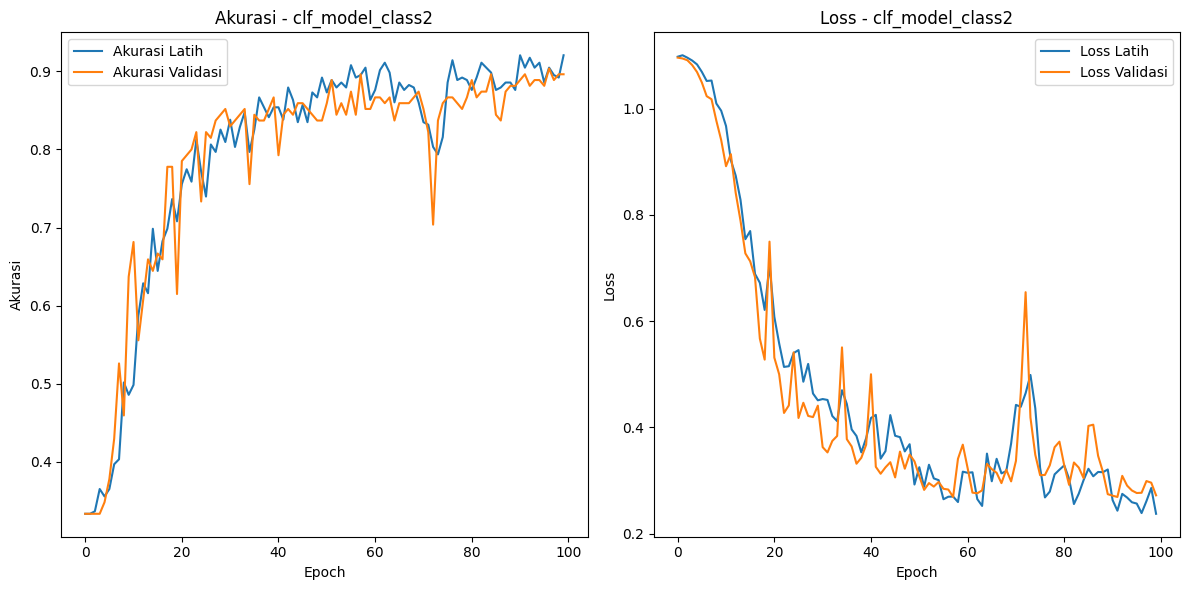

In [ ]:
# Plot History untuk clf_model_class2
plt.figure(figsize=(12, 6))

# Plot Akurasi dan Loss untuk clf_model_class2
plt.subplot(1, 2, 1)  # Subplot pertama untuk akurasi
plt.plot(history_class2.history['accuracy'], label='Akurasi Latih')
plt.plot(history_class2.history['val_accuracy'], label='Akurasi Validasi')
plt.title("Akurasi - clf_model_class2")
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend(loc='best')

plt.subplot(1, 2, 2)  # Subplot kedua untuk loss
plt.plot(history_class2.history['loss'], label='Loss Latih')
plt.plot(history_class2.history['val_loss'], label='Loss Validasi')
plt.title("Loss - clf_model_class2")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.tight_layout()
plt.show()


##**VISUALISASI AKHIR**##

In [ ]:
# Warna RGB untuk setiap kelas
COLOR_MAP = {
    0: [0, 255, 0],    # marcus → hijau
    1: [0, 0, 255],    # miki → biru
    2: [255, 0, 0],    # aligator → merah
}

def colorize_binary_mask(mask, label_idx):
    color = tf.constant(COLOR_MAP.get(label_idx, [255, 255, 255]), dtype=tf.uint8)
    mask = tf.cast(mask > 0.5, tf.uint8)
    mask_rgb = tf.repeat(mask, repeats=3, axis=-1) * color
    return mask_rgb

In [ ]:
def visualize_all_test_images(image_paths, mask_paths, labels, unet_model, clf_model, label_map, max_visualize=None):
    label_names = {v: k for k, v in label_map.items()}
    num_samples = len(image_paths)

    if max_visualize is not None:
        num_samples = min(num_samples, max_visualize)

    for i in range(num_samples):
        image_path = image_paths[i]
        mask_path = mask_paths[i]
        true_label_idx = labels[i]

        # Load image
        image_raw = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(image_raw, channels=3)
        image = tf.image.resize(image, [128, 128])
        image = tf.cast(image, tf.float32) / 255.0

        # Load ground truth mask
        try:
            mask_raw = tf.io.read_file(mask_path)
            gt_mask = tf.image.decode_jpeg(mask_raw, channels=1)
            gt_mask = tf.image.resize(gt_mask, [128, 128])
            gt_mask = tf.cast(gt_mask, tf.float32)
        except:
            gt_mask = tf.zeros((128, 128, 1), dtype=tf.float32)

        # Predict mask with U-Net
        pred_mask = unet_model(tf.expand_dims(image, 0), training=False)
        pred_mask = tf.squeeze(pred_mask, 0)

        # Apply predicted mask for feature extraction
        masked_image = apply_unet_segmentation_to_image(image, pred_mask)

        # Predict label with classifier
        pred_probs = clf_model(tf.expand_dims(masked_image, 0), training=False)
        pred_label_idx = int(tf.argmax(pred_probs, axis=-1).numpy()[0])

        # Convert label to string
        true_label_str = label_names.get(true_label_idx, f"Unknown ({true_label_idx})")
        pred_label_str = label_names.get(pred_label_idx, f"Unknown ({pred_label_idx})")

        # Visualisasi
        fig, axes = plt.subplots(1, 5, figsize=(22, 5))
        axes[0].imshow(image.numpy())
        axes[0].set_title("Original Image")
        axes[0].axis('off')

        axes[1].imshow(colorize_binary_mask(gt_mask, true_label_idx))
        axes[1].set_title("Ground Truth Mask")
        axes[1].axis('off')

        axes[2].imshow(tf.squeeze(pred_mask), cmap='gray')
        axes[2].set_title("Predicted Mask (U-Net)")
        axes[2].axis('off')

        axes[3].imshow(masked_image.numpy())
        axes[3].set_title("Masked Image (Fitur Ekstraksi)")
        axes[3].axis('off')

        axes[4].imshow(masked_image.numpy())
        axes[4].set_title(f"Label Asli: {true_label_str}\nPrediksi: {pred_label_str}")
        axes[4].axis('off')

        filename = image_path.split('/')[-1]
        plt.suptitle(f"Visualisasi: {filename}", fontsize=14, y=1.05)
        plt.tight_layout()
        plt.show()

Daftar warna ground truth untuk setiap jenis daun:
- marcus: merah
- miki: hijau
- aligator: biru


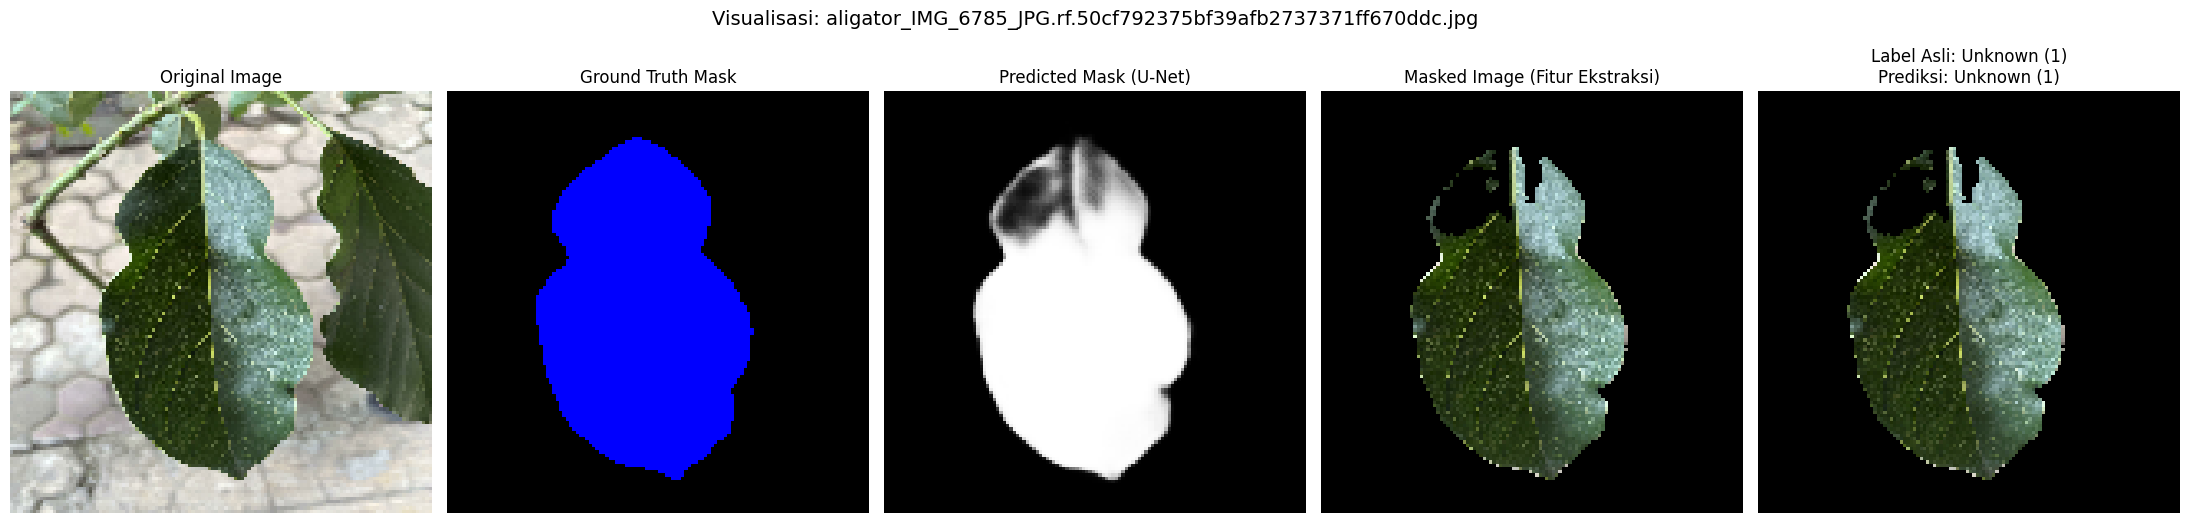

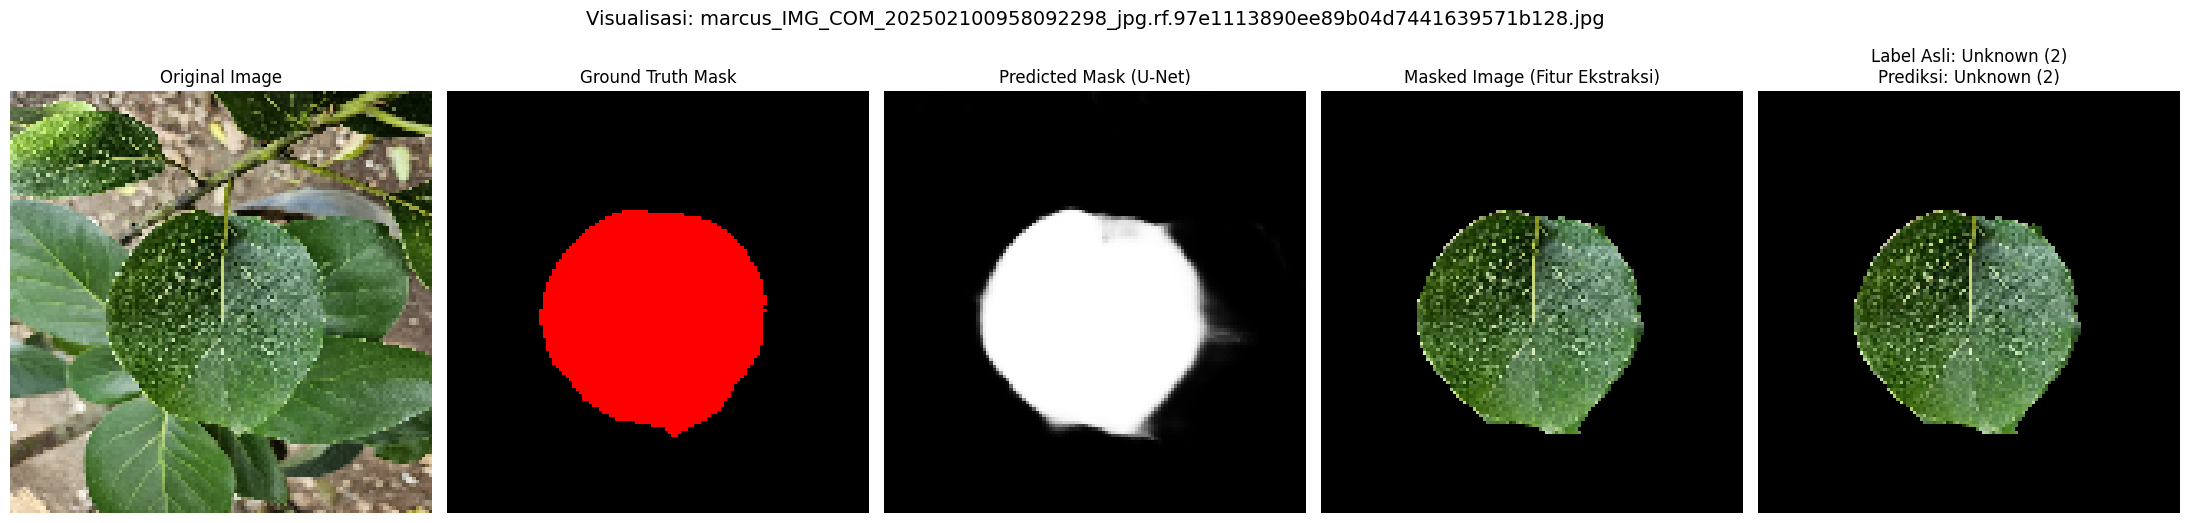

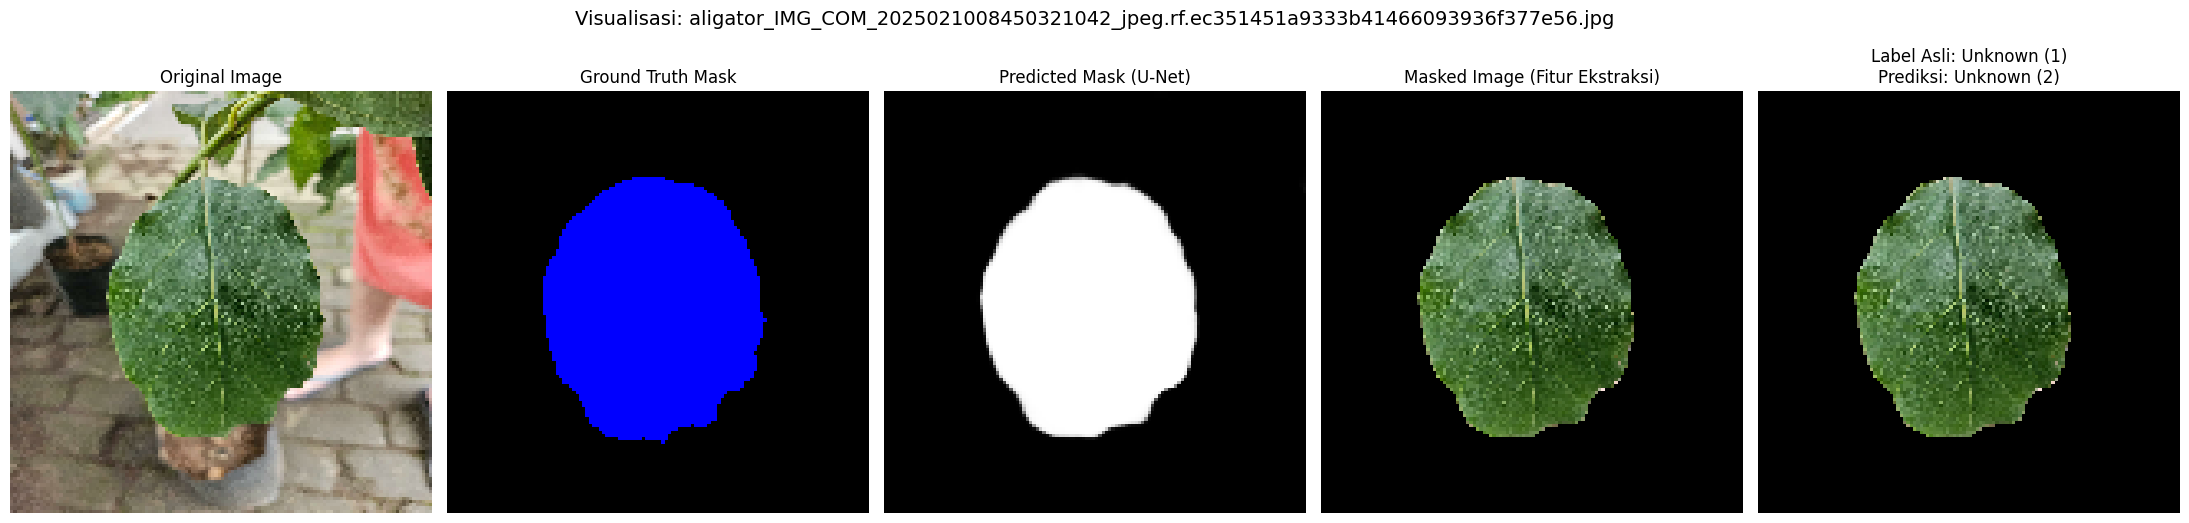

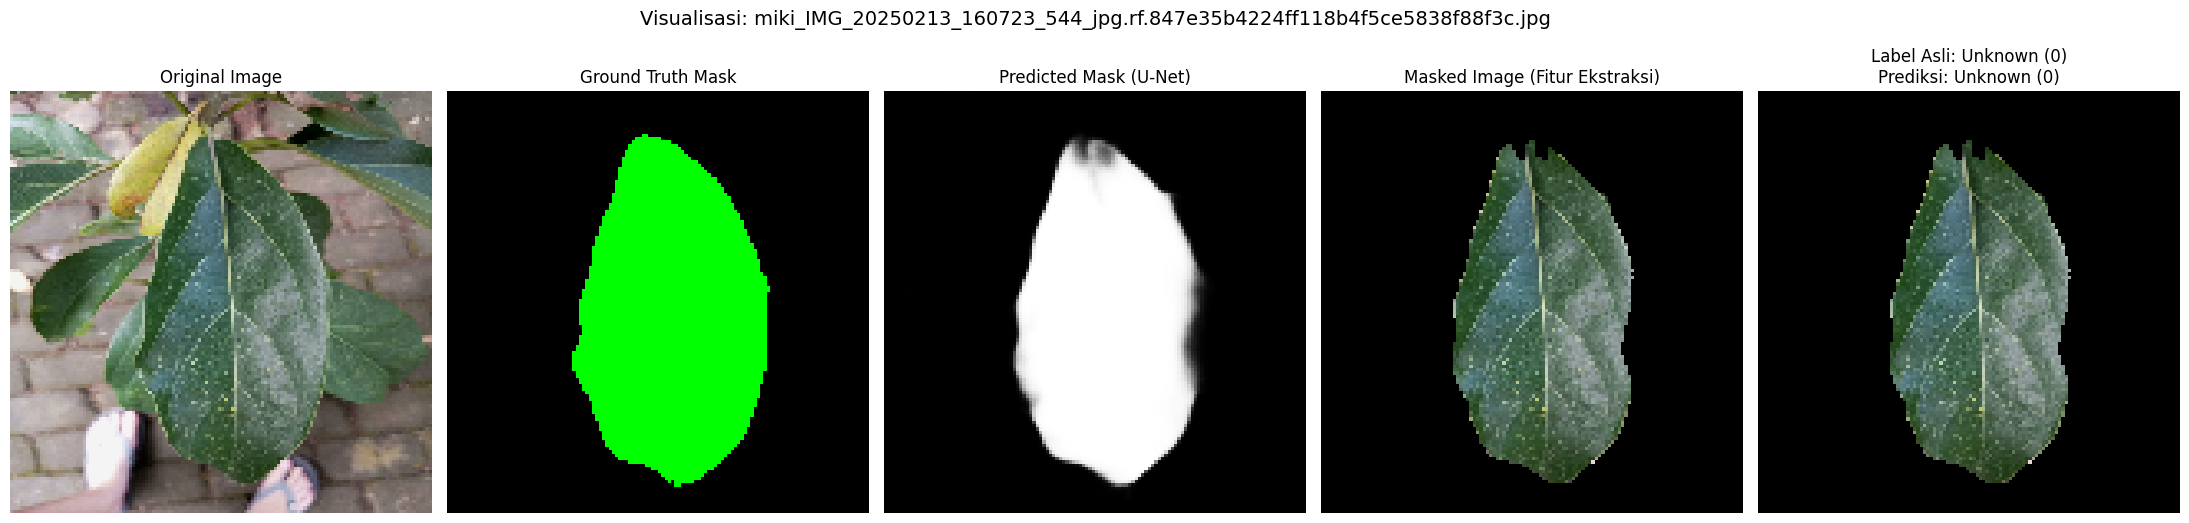

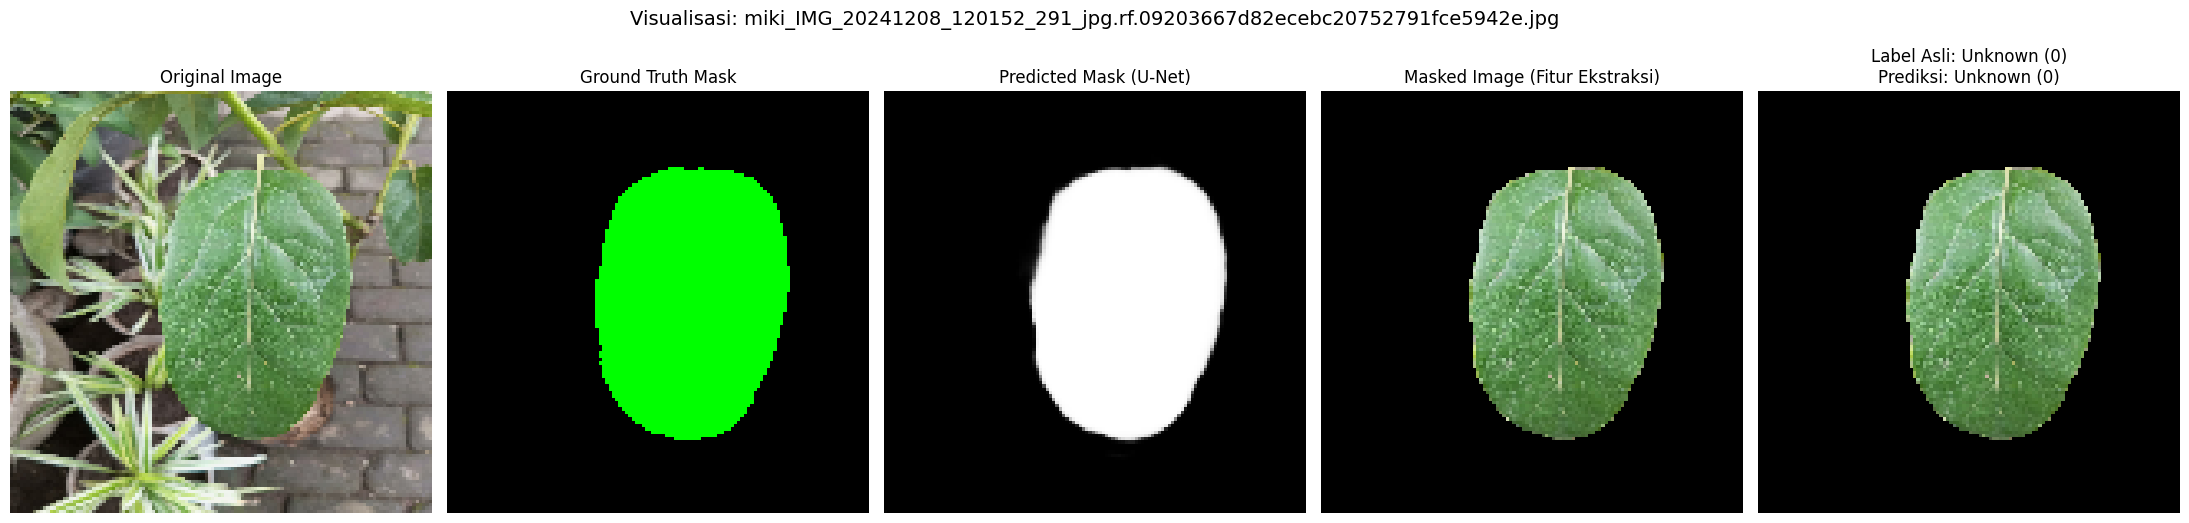

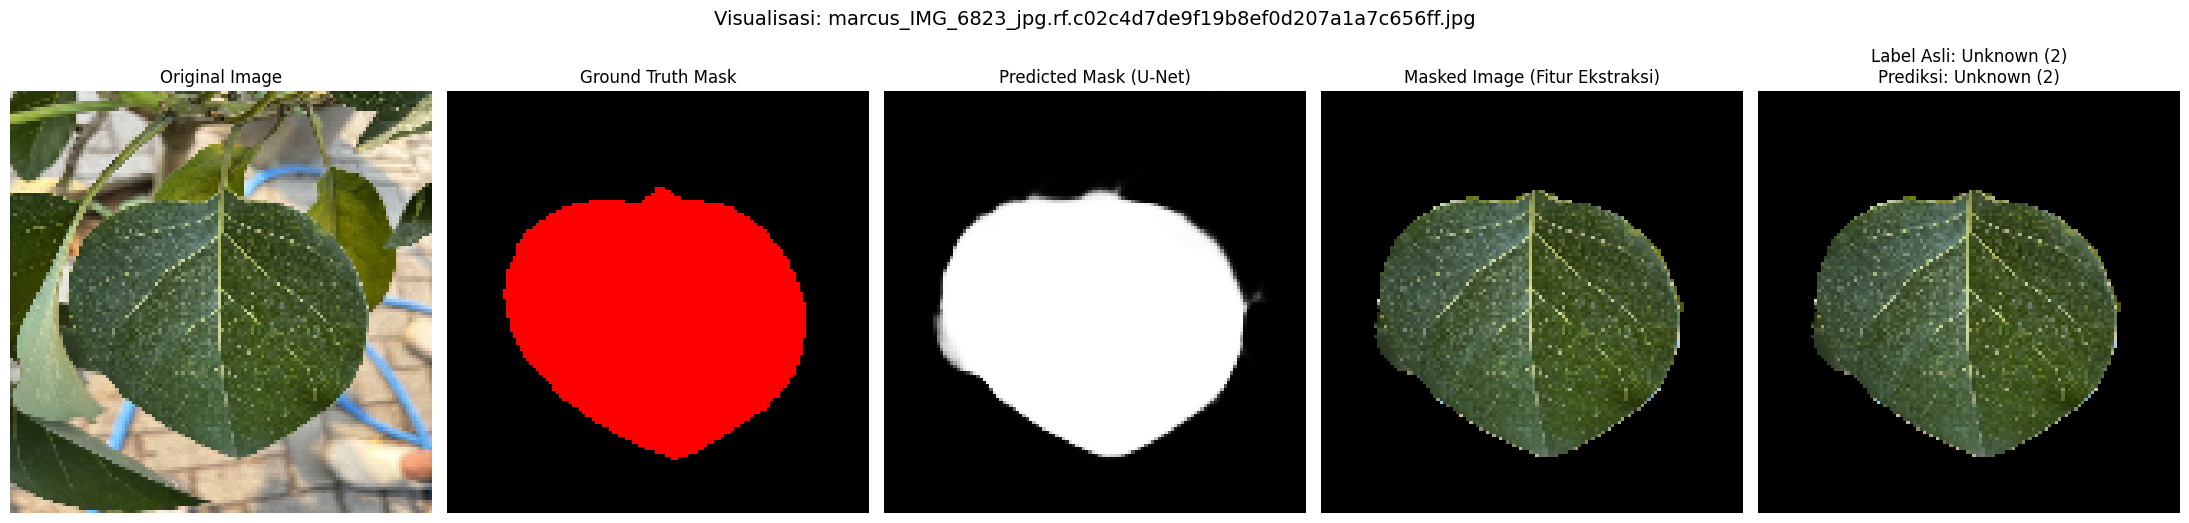

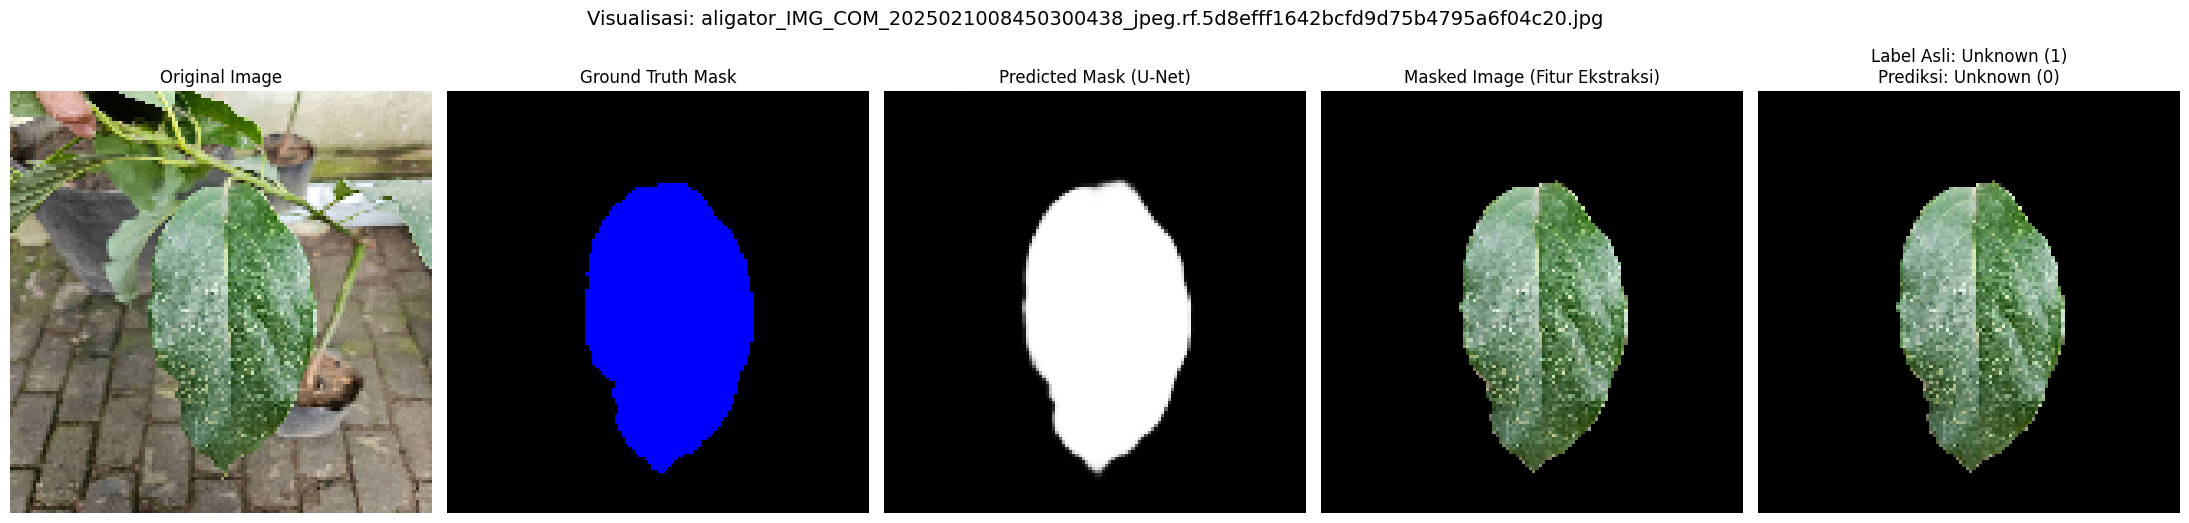

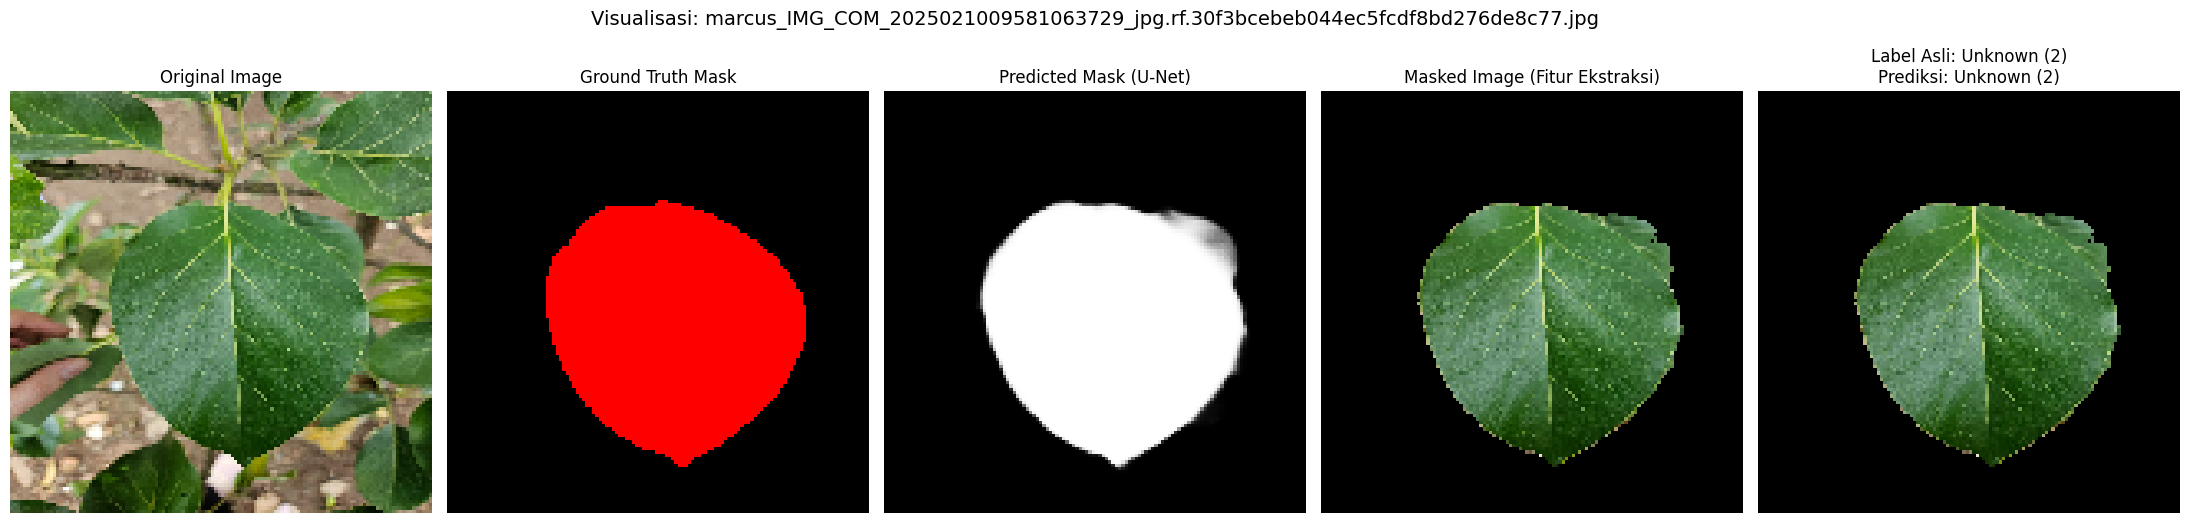

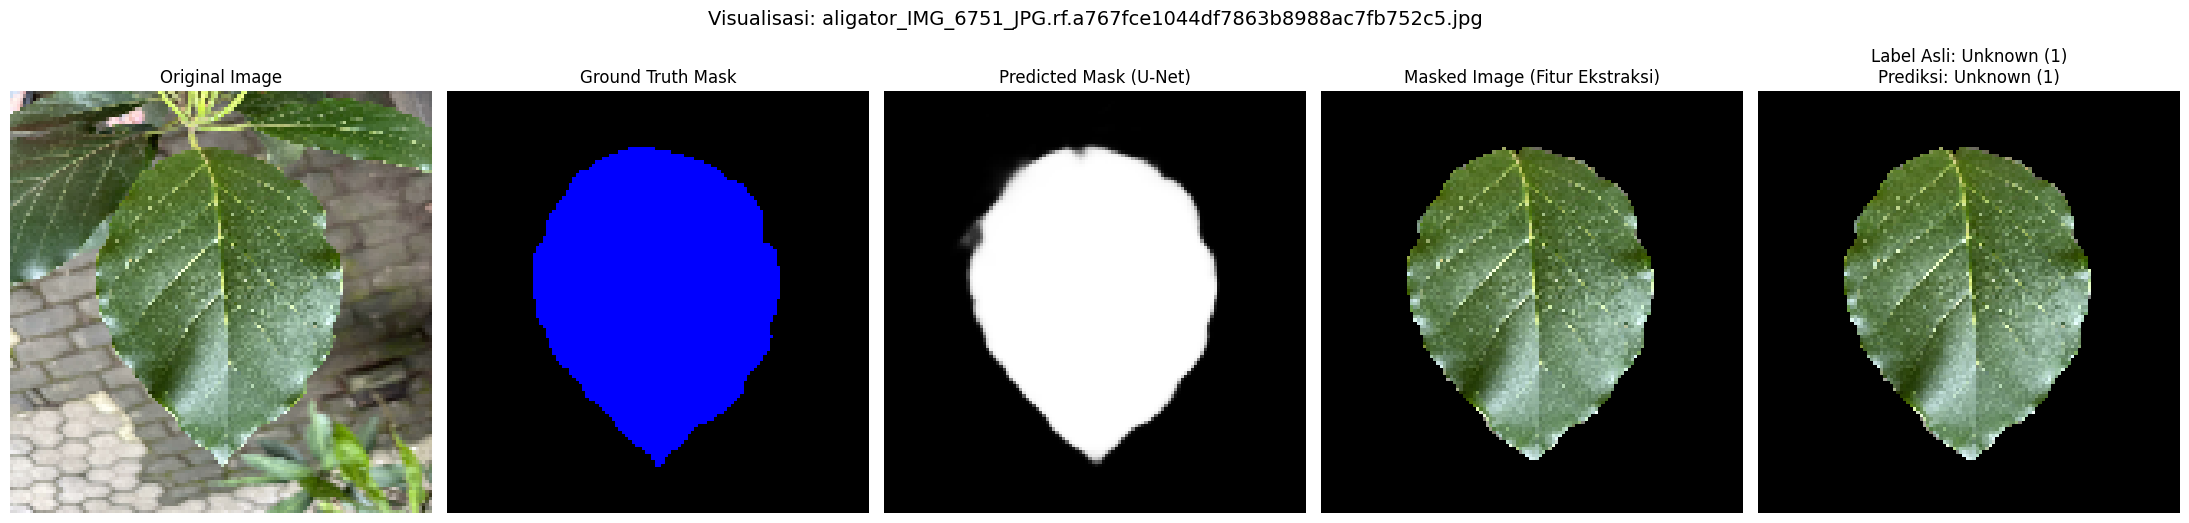

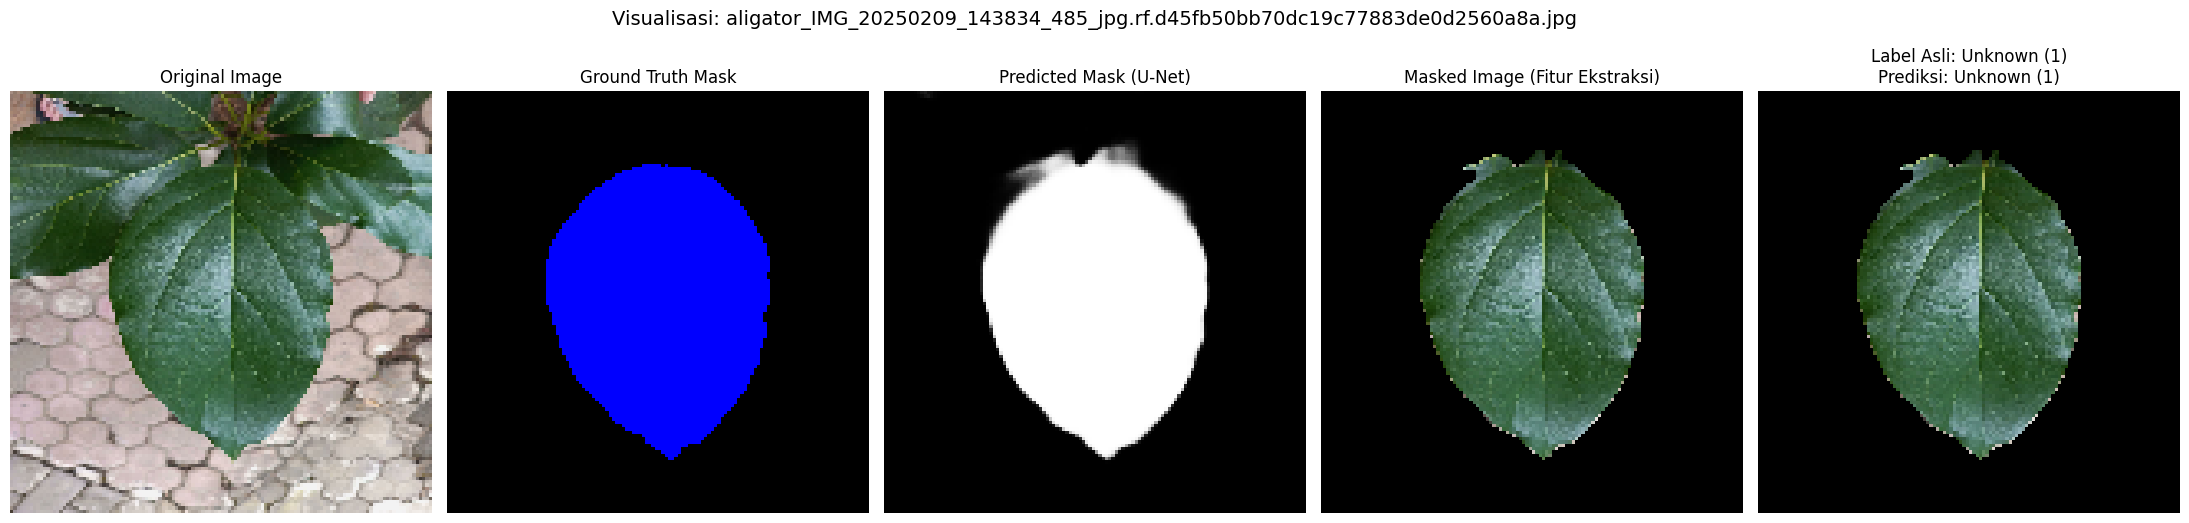

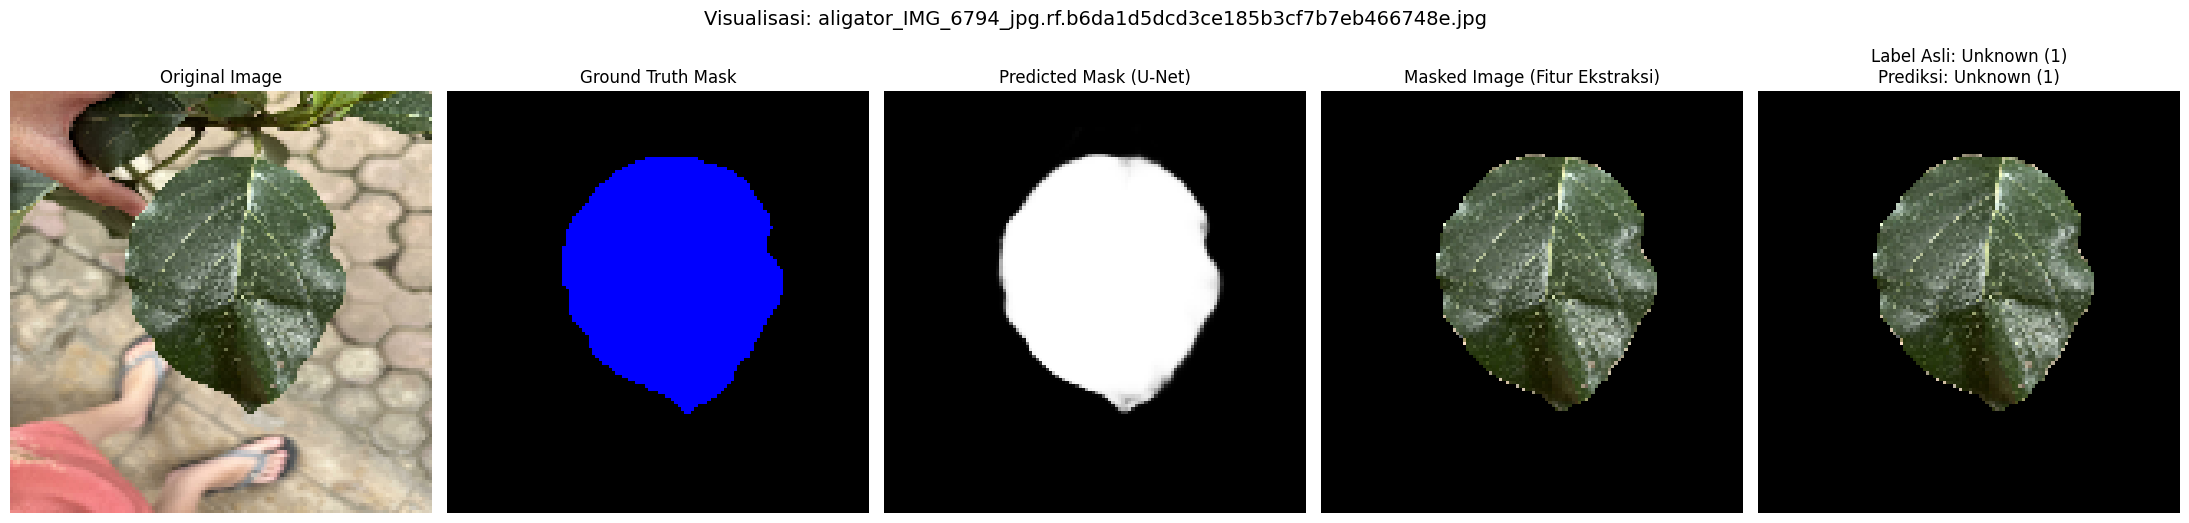

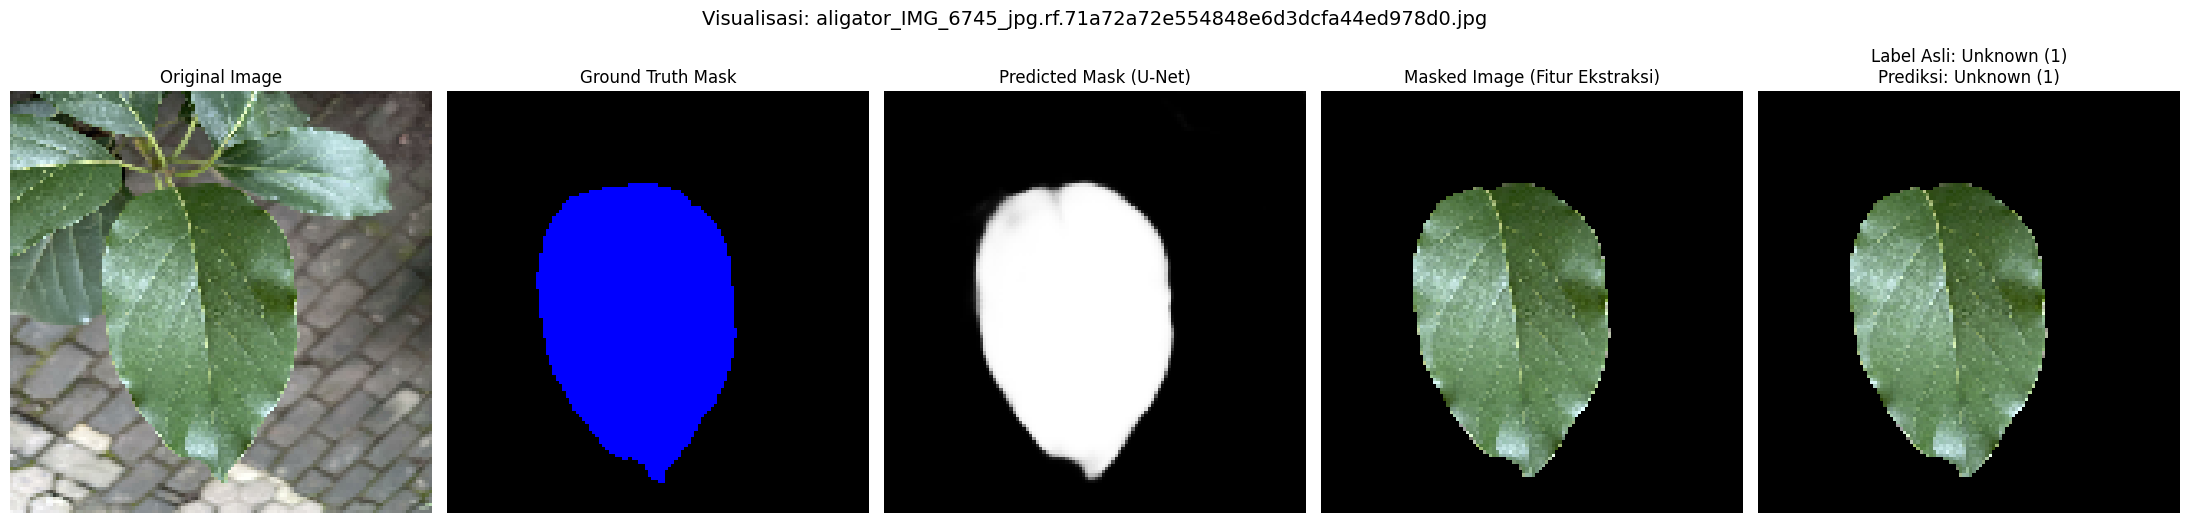

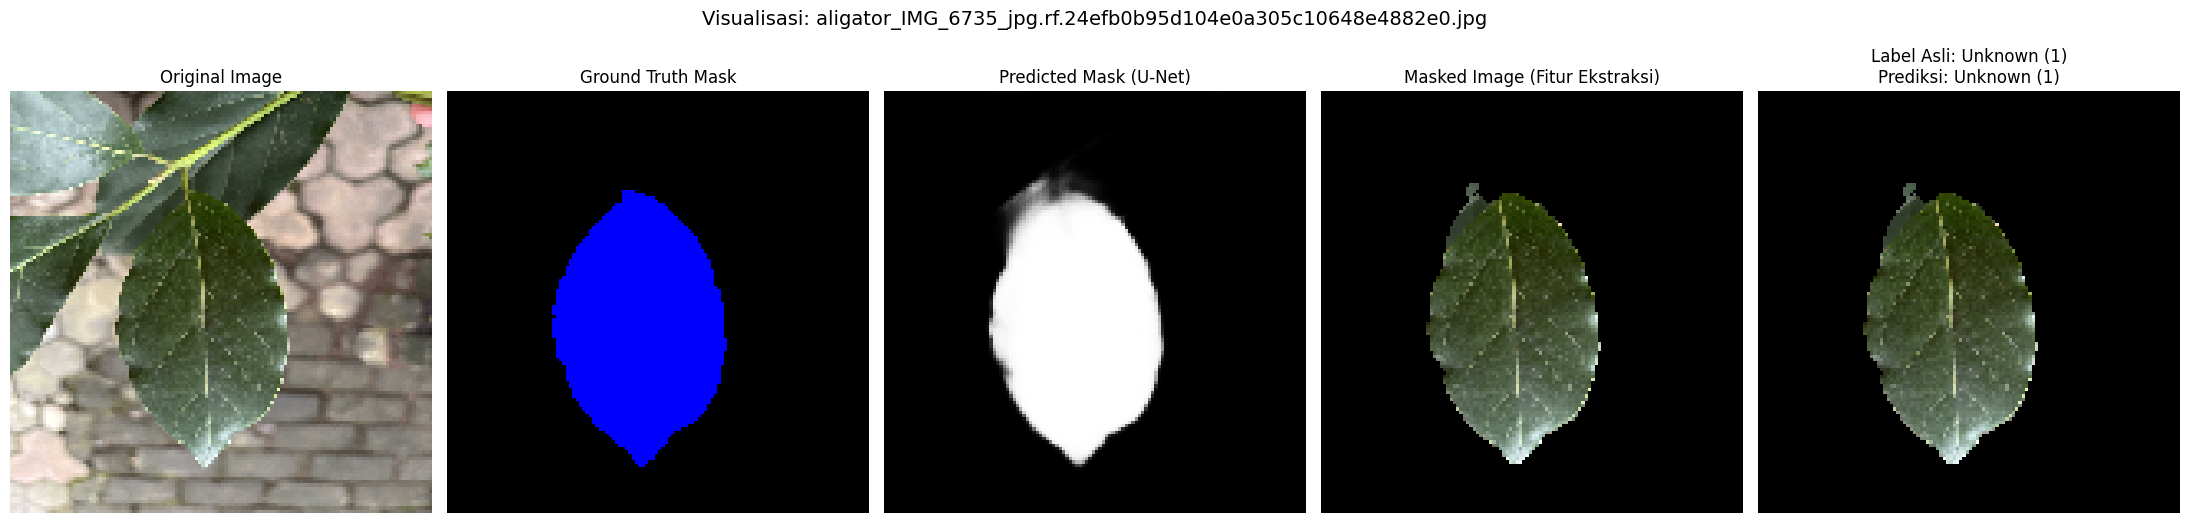

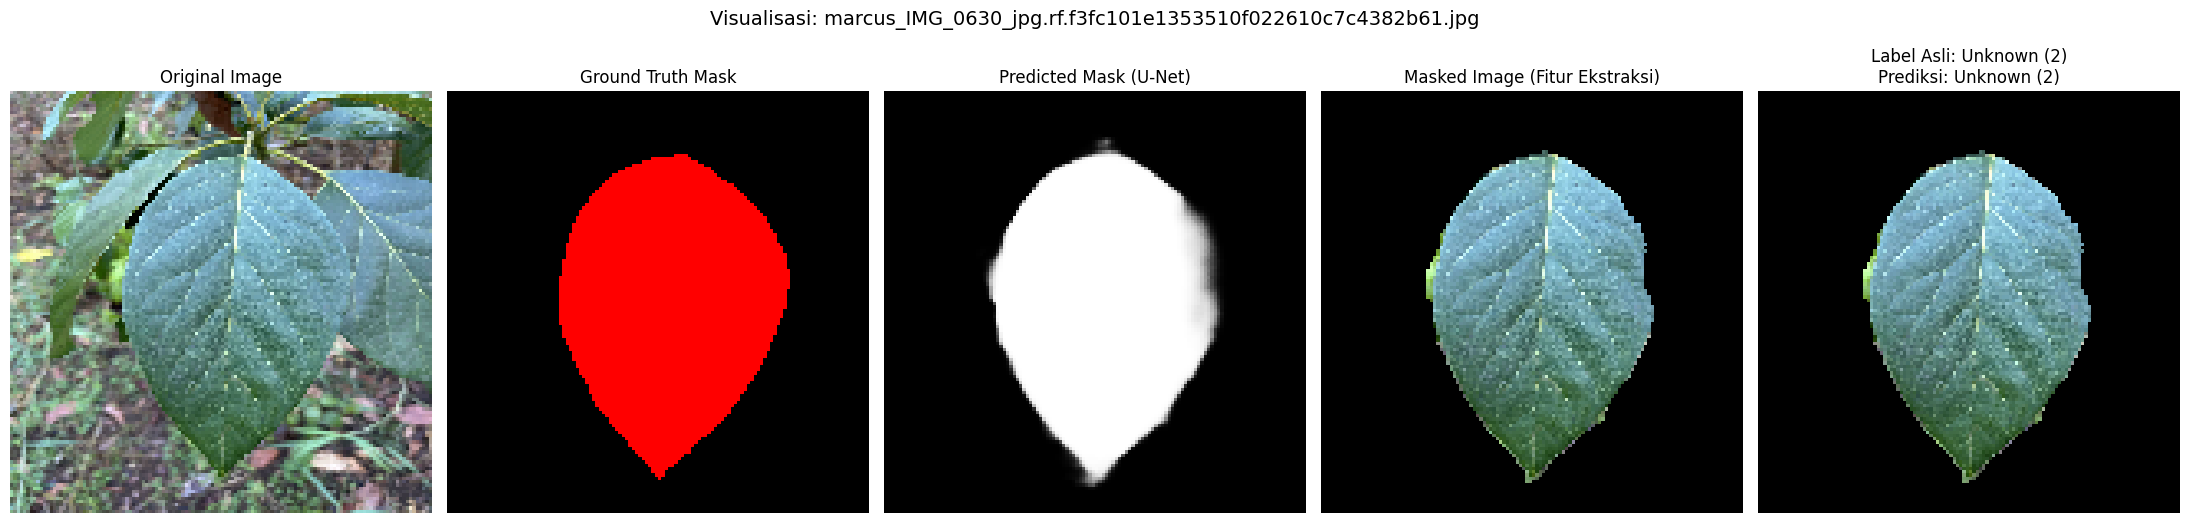

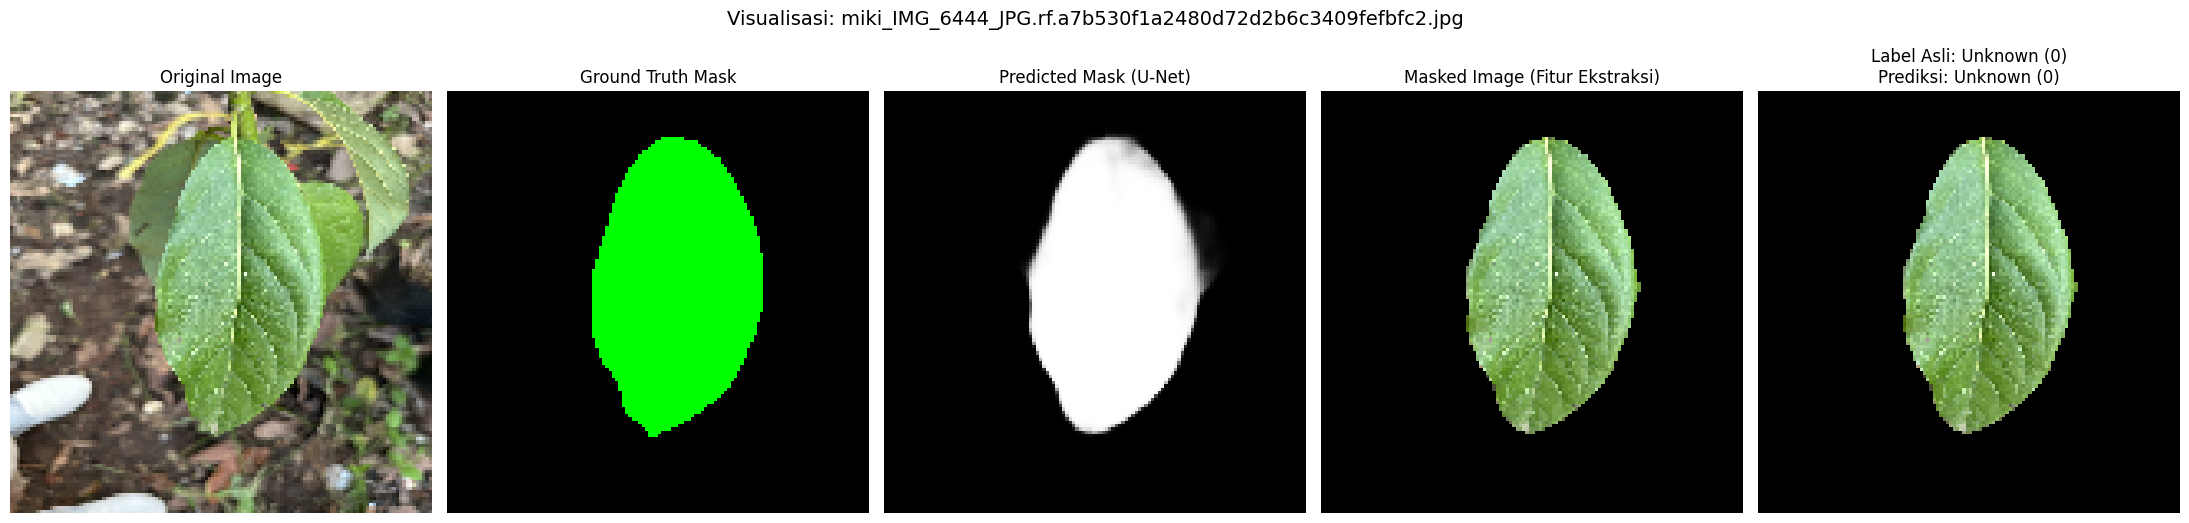

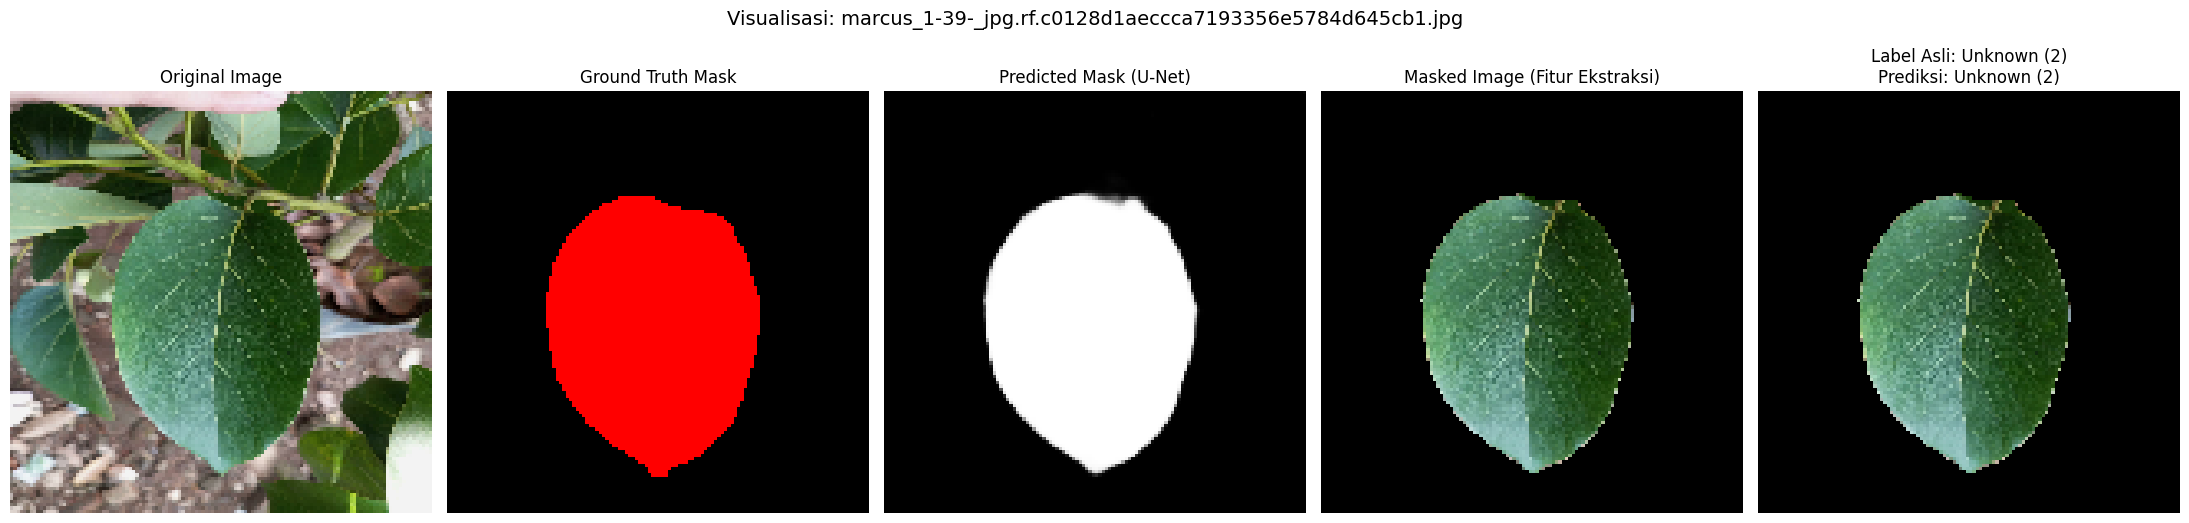

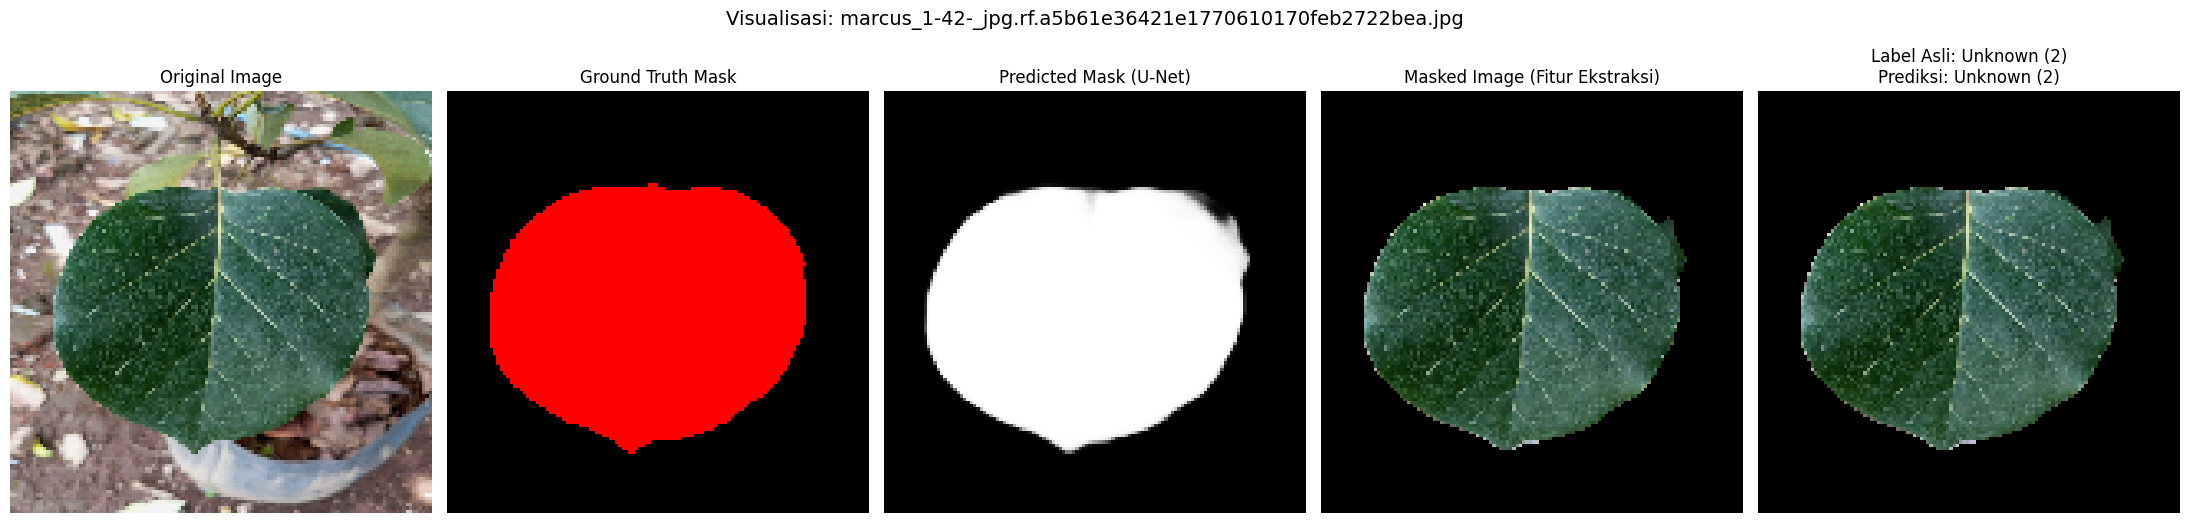

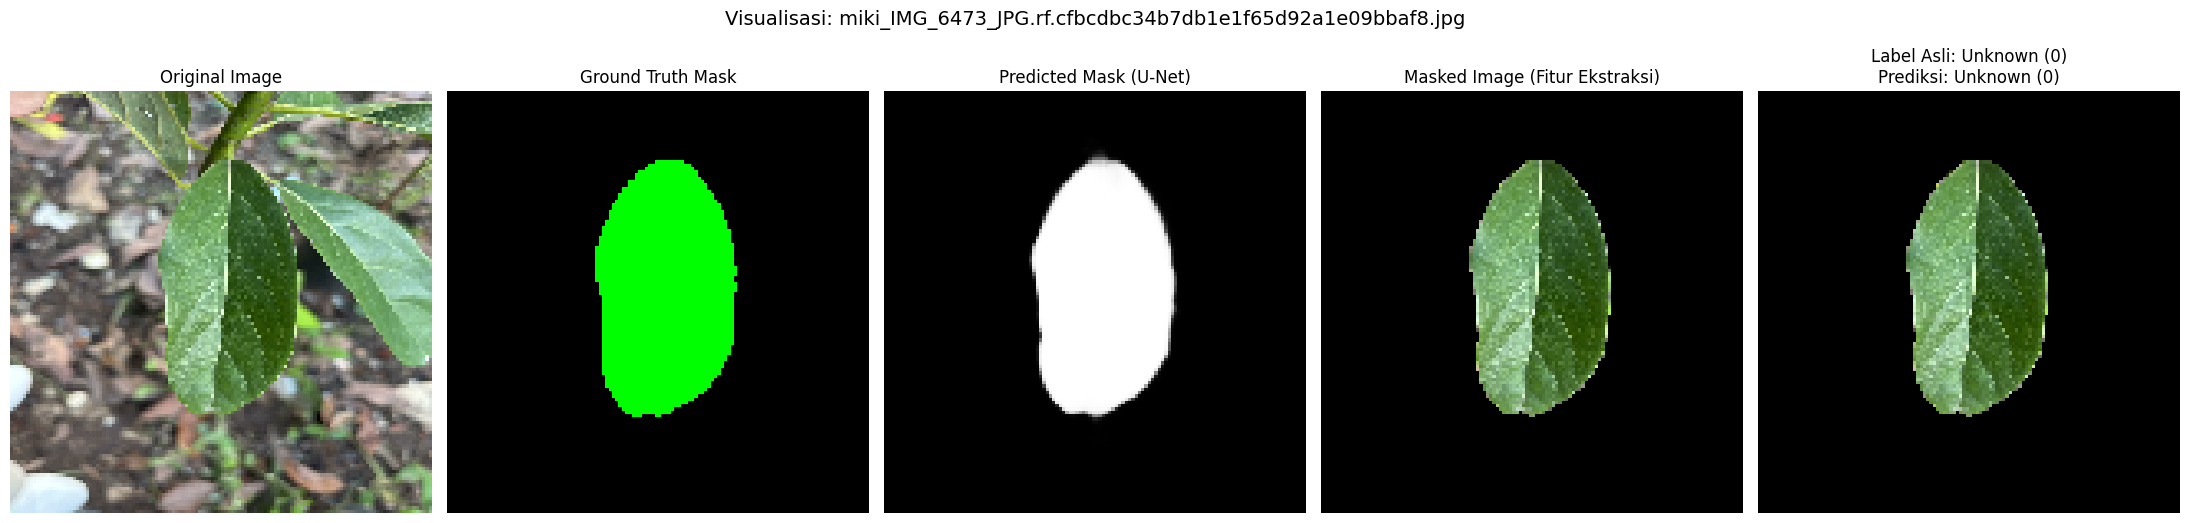

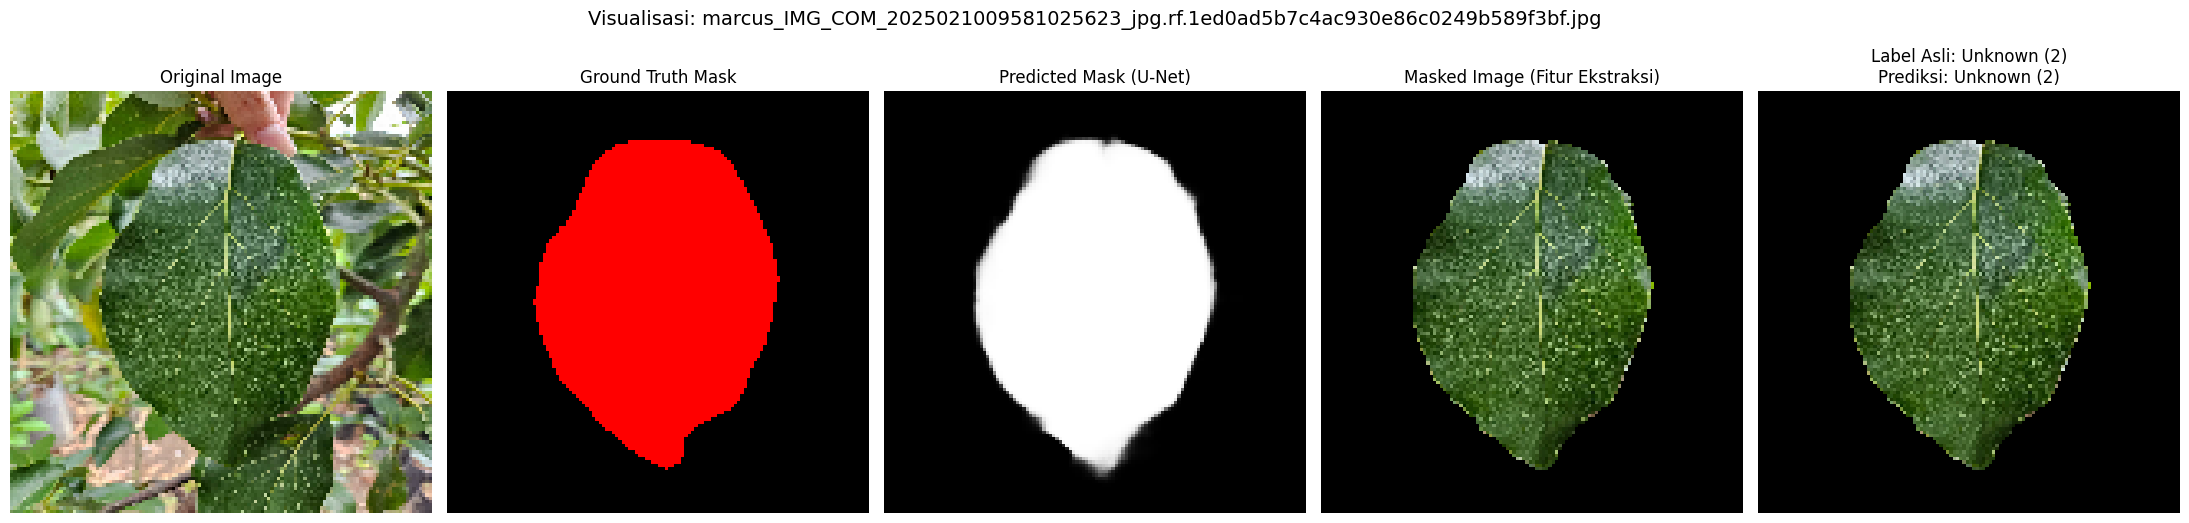

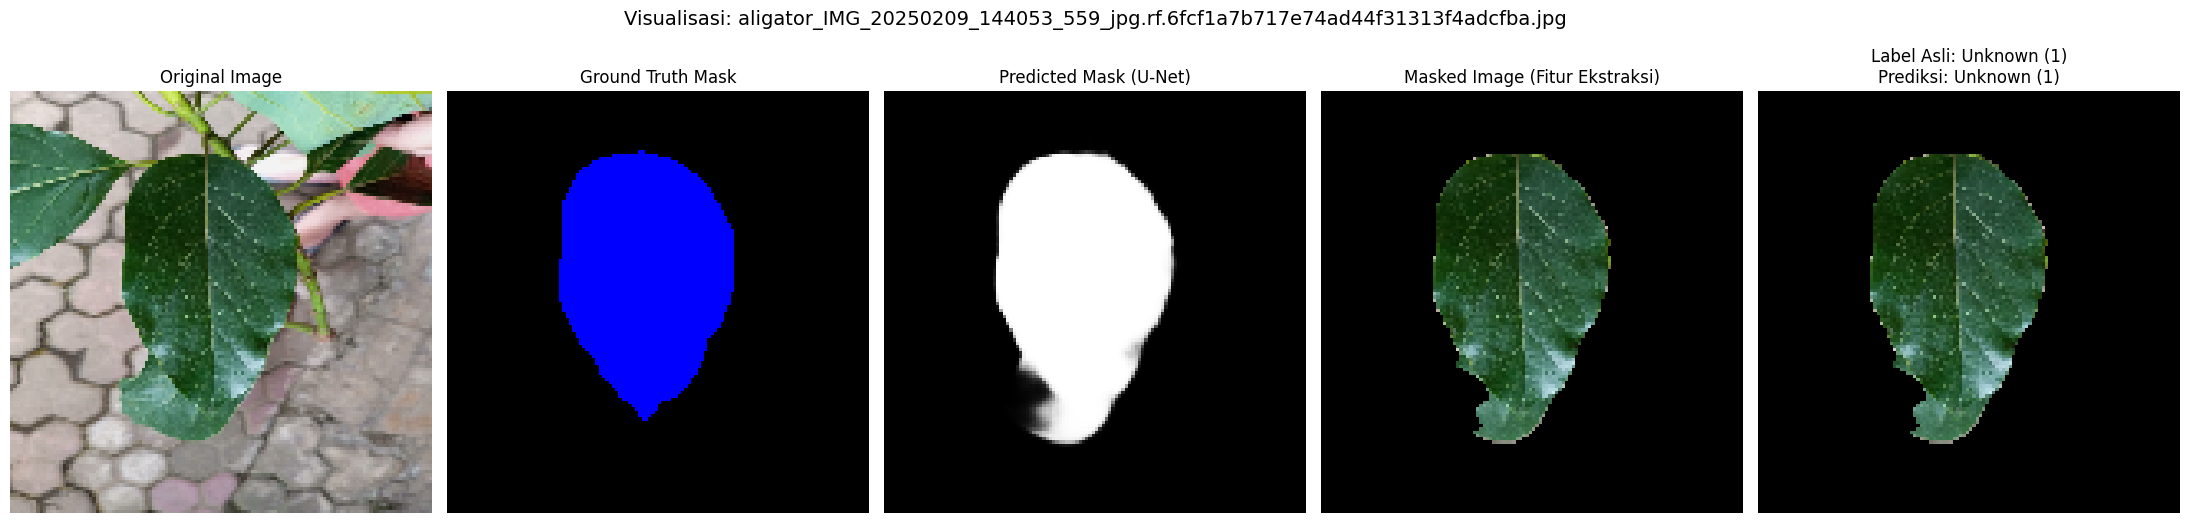

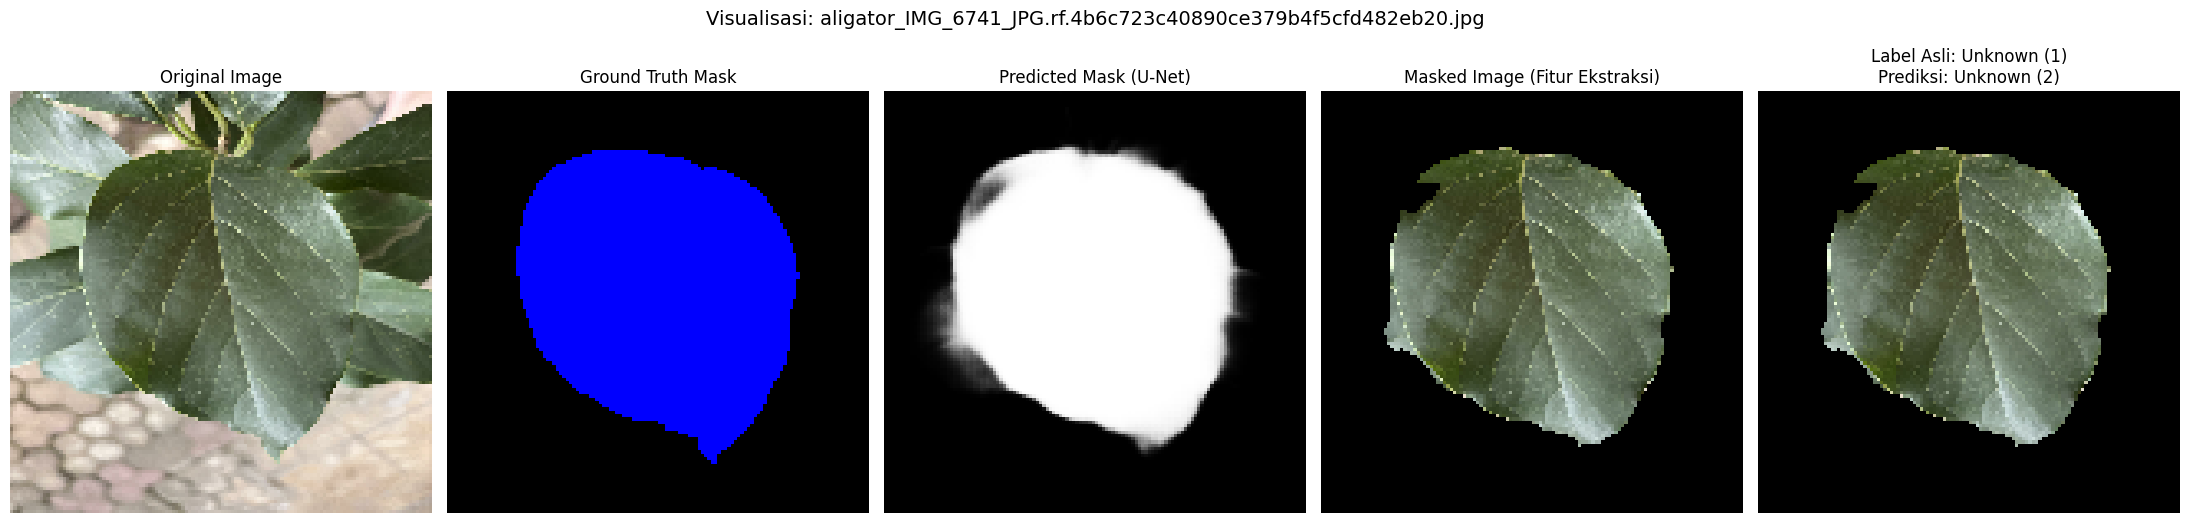

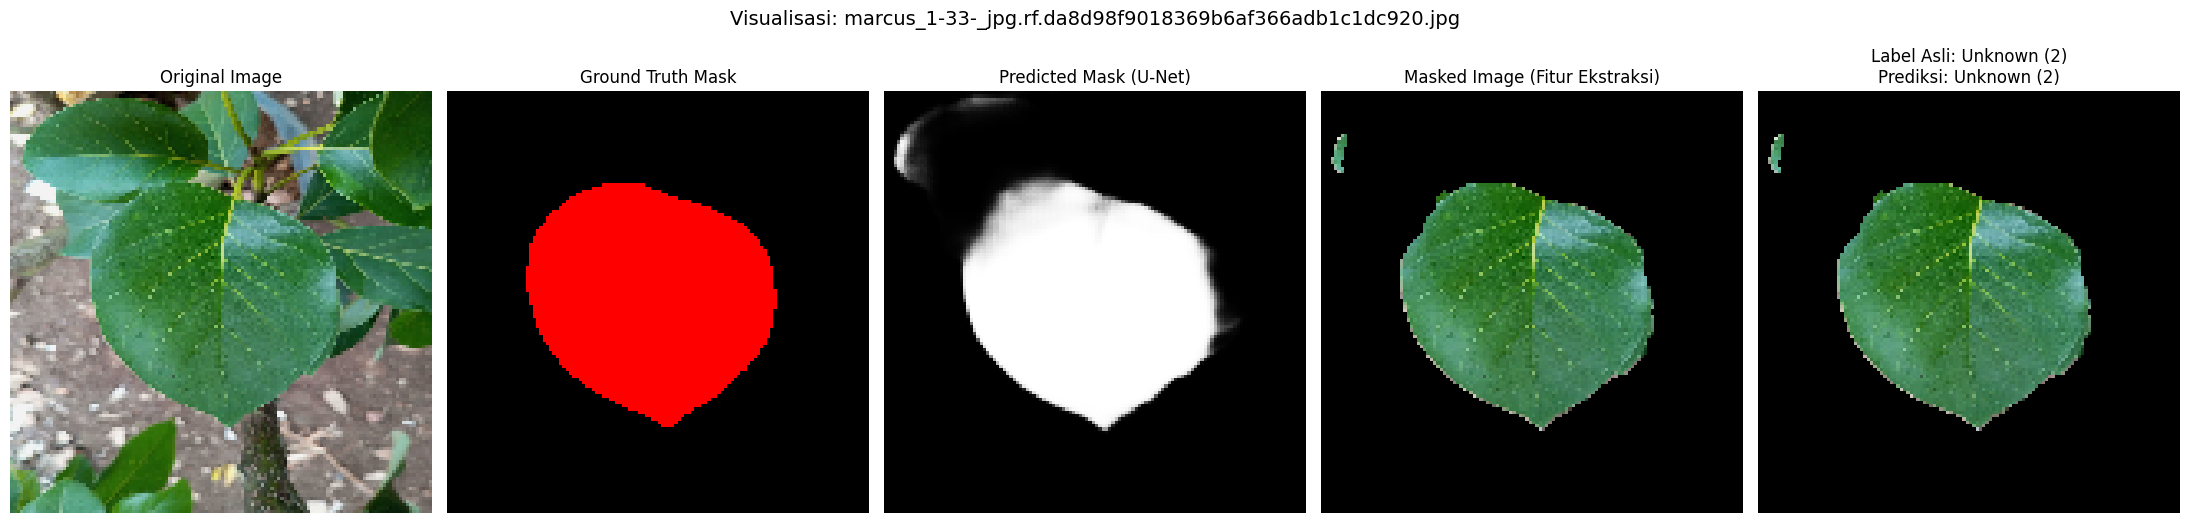

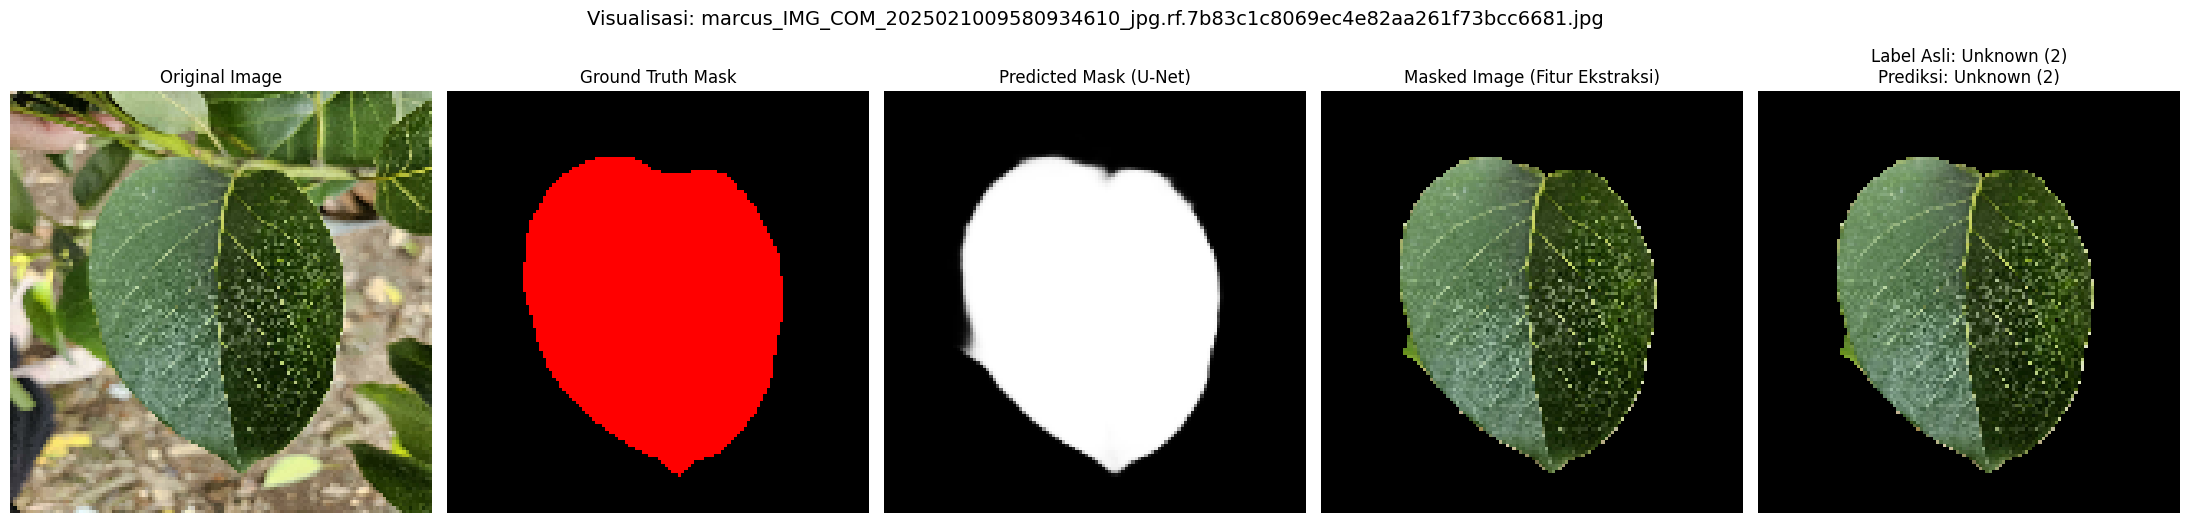

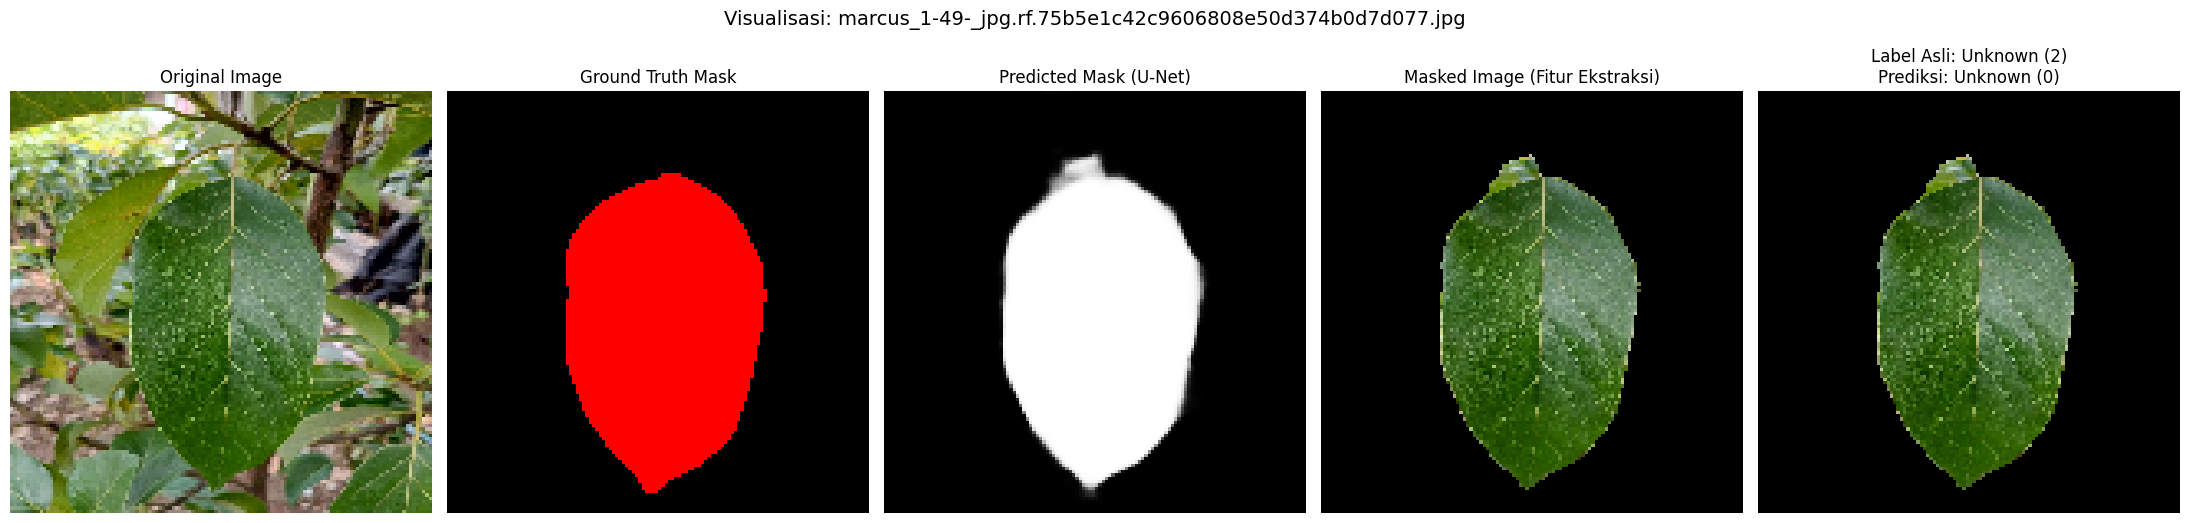

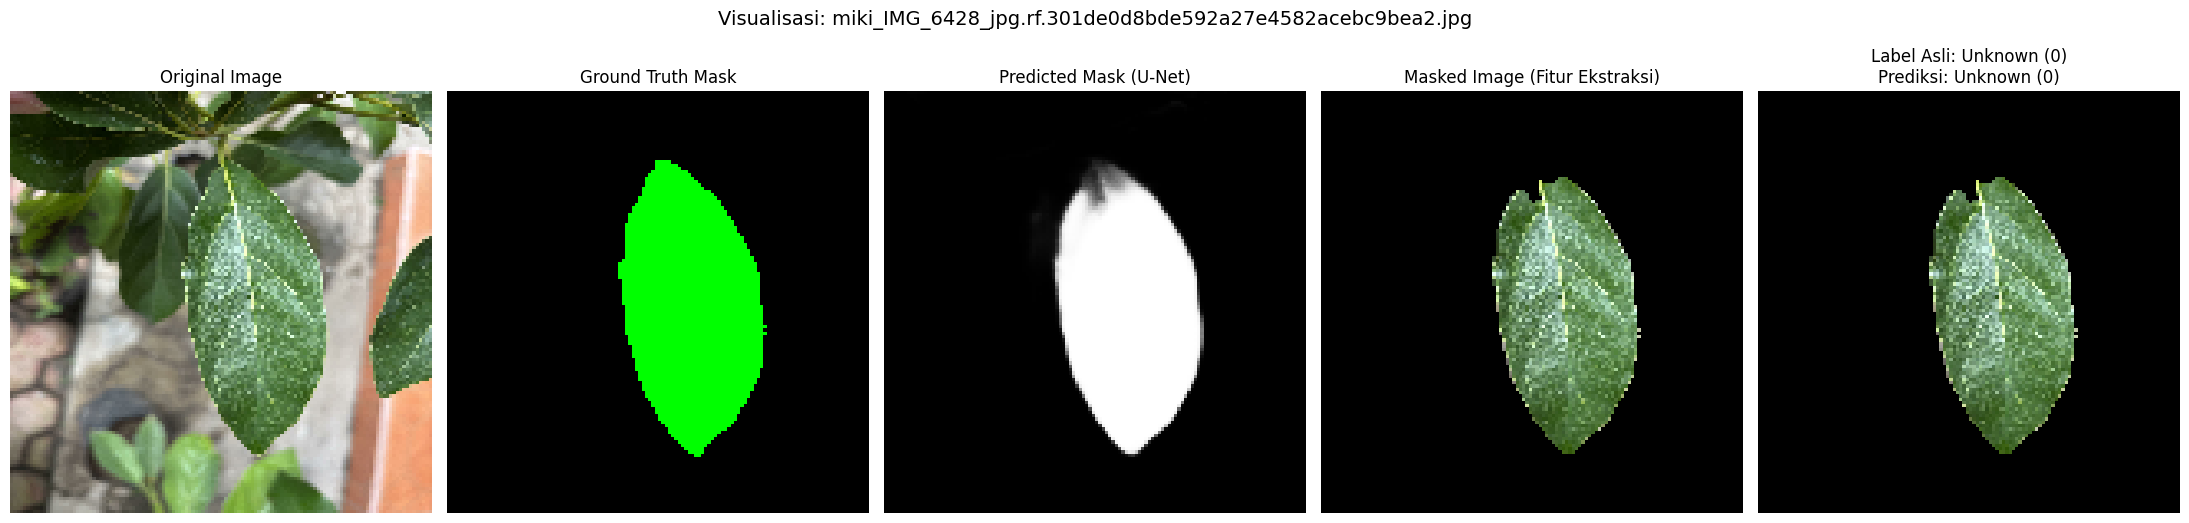

In [ ]:
# Cetak warna untuk setiap jenis daun tanpa menampilkan RGB
mapping = {
    "marcus": "merah",
    "miki": "hijau",
    "aligator": "biru"
}

print("Daftar warna ground truth untuk setiap jenis daun:")
for label, warna in mapping.items():
    print(f"- {label}: {warna}")


visualize_all_test_images(
    test_image_paths,
    test_mask_paths,
    test_labels,
    unet_model,
    clf_model_class1,
    label_map,
    max_visualize=25  # Ganti jumlah yang ingin divisualisasikan
)